<h1>Feature analysis and selection</h1>

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<h2>Preprocessing</h2>

In [5]:
# importing the data from kagglehub
import kagglehub
path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")
# importing the data in the kernel
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")
# uniting and shuffling the data to avoid order bias
data_all = pd.concat([data_train, data_test], axis=0, ignore_index=True)
data_all = data_all.sample(frac=1, random_state=42).reset_index(drop=True)
# separating the features and the target variable
data_X = data_all.drop(columns=['device_category'])
data_y = data_all['device_category']

In [6]:
# encoding the target variable
dummies = pd.get_dummies(data_y, dtype=int)
device_categories = dummies.columns.tolist()

In [7]:
print(len(data_X.columns), "features")

297 features


There's way too many dimensions.

<h2>Calculating feature correlations</h2>

In [8]:
# feature correlations with each other
feature_correlations = data_X.corr()

In [9]:
# feature correlations with the target variable
corr_per_deviceCategory = []    # list of dataframes containing correlations between features and each device category
for category in device_categories:
    corr_per_deviceCategory.append(pd.concat([data_X, dummies[category]], axis=1).corr().abs()[category].sort_values(ascending=False))
# removing each device category's self-correlation
for i in range(len(corr_per_deviceCategory)):
    corr_per_deviceCategory[i] = corr_per_deviceCategory[i].drop(device_categories[i])

In [10]:
print(corr_per_deviceCategory)

[ttl_B_min                   0.496075
reset_B                     0.370424
ttl_A_avg                   0.308538
ttl_A_firstQ                0.308538
ttl_A_max                   0.308538
                              ...   
suffix_is_co.il                  NaN
suffix_is_com.sg                 NaN
suffix_is_googleapis.com         NaN
suffix_is_net                    NaN
suffix_is_org                    NaN
Name: TV, Length: 297, dtype: float64, reset_A                     0.660903
reset                       0.565487
ttl_B_stdev                 0.517958
ttl_B_max                   0.482812
ttl_B_thirdQ                0.469859
                              ...   
suffix_is_co.il                  NaN
suffix_is_com.sg                 NaN
suffix_is_googleapis.com         NaN
suffix_is_net                    NaN
suffix_is_org                    NaN
Name: baby_monitor, Length: 297, dtype: float64, packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arri

<h2>Analyzing feature correlations per device category</2>

<h3>Most correlated features per device category</h3>

In [11]:
# lets only keep the top 10 correlated features for each category
corr_per_deviceCategory_top10 = []
for category in device_categories:
    corr_per_deviceCategory_top10.append(corr_per_deviceCategory[device_categories.index(category)].head(10))
# turning the list into a dictionary to make it easier to work with
corr_per_deviceCategory_top10_dict = {}
for i in range(len(device_categories)):
    corr_per_deviceCategory_top10_dict[device_categories[i]] = corr_per_deviceCategory_top10[i]

<h4>Grouping most correlated features by what they refer to</h4>

In [12]:
# getting a list of all unique features in the top 10 of each device category
features_mostCorrelated = set()
for i in range(len(device_categories)):
    top_corr = corr_per_deviceCategory_top10[i]
    if device_categories[i] in top_corr.index:
        top_corr = top_corr.drop(device_categories[i])
    features_mostCorrelated.update(top_corr.index)
features_mostCorrelated = list(features_mostCorrelated)
# order elements of features alphabetically
features_mostCorrelated.sort()
print(features_mostCorrelated)
print(len(features_mostCorrelated), "features in the top 10 of each device category")

['B_port_is_11095', 'B_port_is_8080', 'domain_is_else', 'ds_field_B', 'http_count_host', 'http_count_req_content_type', 'http_count_resp_code', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min', 'packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packets_A_B_ratio', 'reset', 'reset_A', 'reset_B', 'ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ssl_req_bytes_var', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_min', 'ttl_B_stdev', 'ttl_B_thirdQ', 'ttl_B_va

In [13]:
features_mostCorrelated_groups = {
    'B_port': [feature for feature in features_mostCorrelated if feature.startswith('B_port')],
    'http': [feature for feature in features_mostCorrelated if feature.startswith('http') or feature == 'is_http'],
    'packet_inter': [feature for feature in features_mostCorrelated if feature.startswith('packet_inter')],
    'packet_size': [feature for feature in features_mostCorrelated if feature.startswith('packet_size')],
    'reset': [feature for feature in features_mostCorrelated if feature.startswith('reset')],
    'ssl': [feature for feature in features_mostCorrelated if feature.startswith('ssl')],
    'ttl_A': [feature for feature in features_mostCorrelated if feature.startswith('ttl_A')],
    'ttl_B': [feature for feature in features_mostCorrelated if feature.startswith('ttl_B')],
    'ttl_all': [feature for feature in features_mostCorrelated if feature.startswith('ttl_') and not feature.startswith('ttl_A') and not feature.startswith('ttl_B')],
    'other': []
}
features_not_in_other = []
for key, value in features_mostCorrelated_groups.items():
    features_not_in_other.extend(value)
for feature in features_mostCorrelated:
    if feature not in features_not_in_other:
        features_mostCorrelated_groups['other'].append(feature)
print(features_mostCorrelated_groups)

{'B_port': ['B_port_is_11095', 'B_port_is_8080'], 'http': ['http_count_host', 'http_count_req_content_type', 'http_count_resp_code', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http'], 'packet_inter': ['packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min'], 'packet_size': ['packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ'], 'reset': ['reset', 'reset_A', 'reset_B'], 'ssl': ['ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ssl_req_bytes_var'], 'ttl_A': ['ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ'], 'ttl_B': ['ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_m

<h4>Correlation metrics per feature and feature group to analyze most important features</h4>

In [14]:
# number of device categories each feature is in the top 10 of
features_mostCorrelated_prevalence = {feature: 0 for feature in features_mostCorrelated}
for i in range(len(device_categories)):
    top_corr = corr_per_deviceCategory_top10[i]
    if device_categories[i] in top_corr.index:
        top_corr = top_corr.drop(device_categories[i])
    for feature in top_corr.index:
        features_mostCorrelated_prevalence[feature] += 1

In [15]:
# sum of the correlations of each feature with all device categories
features_mostCorrelated_correlationSum = {feature: 0 for feature in features_mostCorrelated}
for items in corr_per_deviceCategory_top10_dict.values():
    for feature in items.index:
        features_mostCorrelated_correlationSum[feature] += items[feature]

In [16]:
features_mostCorrelated_analysis = pd.DataFrame(index=features_mostCorrelated)
features_mostCorrelated_analysis['prevalence'] = features_mostCorrelated_prevalence.values()
features_mostCorrelated_analysis['correlation_sum'] = features_mostCorrelated_correlationSum.values()
features_mostCorrelated_analysis['avg_correlation'] = features_mostCorrelated_analysis['correlation_sum'] / features_mostCorrelated_analysis['prevalence']
features_mostCorrelated_analysis['group'] = features_mostCorrelated_analysis.index.map(
    lambda x: next((group for group, features in features_mostCorrelated_groups.items() if x in features), 'others')
)
features_mostCorrelated_analysis.head(10)

,prevalence,correlation_sum,avg_correlation,group
B_port_is_11095,1,0.687184,0.687184,B_port
B_port_is_8080,3,1.507778,0.502593,B_port
domain_is_else,1,0.736364,0.736364,other
ds_field_B,3,1.495379,0.498460,other
http_count_host,1,0.725062,0.725062,http
http_count_req_content_type,1,0.725062,0.725062,http
http_count_resp_code,1,0.724871,0.724871,http
http_count_resp_content_type,1,0.724871,0.724871,http
http_count_user_agents,1,0.725062,0.725062,http
http_has_req_content_type,1,0.725062,0.725062,http


In [17]:
import plotly.express as px
fig_corr = px.sunburst(
    features_mostCorrelated_analysis, 
    path=['group', features_mostCorrelated_analysis.index], 
    values='correlation_sum',
    color='avg_correlation', color_continuous_scale='Blues',
    title='Feature importance'
    )
fig_corr.show()

<h4>Visualizing most correlated features per device category and feature type</h4>

In [18]:
import matplotlib

In [19]:
cmap = matplotlib.colormaps['gist_rainbow']
cmap_feature_groups = {group: cmap(i / len(features_mostCorrelated_groups.keys())) for i, group in enumerate(features_mostCorrelated_groups.keys())}
cmap_features = {row[0]: cmap_feature_groups[row[1].group] for row in features_mostCorrelated_analysis.iterrows()}
cmap_features_perDeviceCategory = {device_category: {feature: cmap_features[feature] for feature in features_mostCorrelated} for device_category in device_categories}

In [20]:
device_category_names = {
    'TV': 'TV',
    'baby_monitor': 'Baby monitor',
    'lights': 'Lights',
    'motion_sensor': 'Motion sensor',
    'security_camera': 'Security camera',
    'smoke_detector': 'Smoke detector',
    'socket': 'Socket',
    'thermostat': 'Thermostat',
    'watch': 'Watch',
    'water_sensor': 'Water sensor'
}

In [21]:
feature_group_names = {
    'B_port': 'B ports',
    'http': 'HTTP features',
    'packet_inter': 'Iter-arrival time between packets',
    'packet_size': 'Packet size',
    'reset': 'Reset packets',
    'ssl': 'SSL features',
    'ttl_A': 'Time To Live of A packets',
    'ttl_B': 'Time To Live of B packets',
    'ttl_all': 'Time To Live of all packets',
    'other': 'Other features'
}

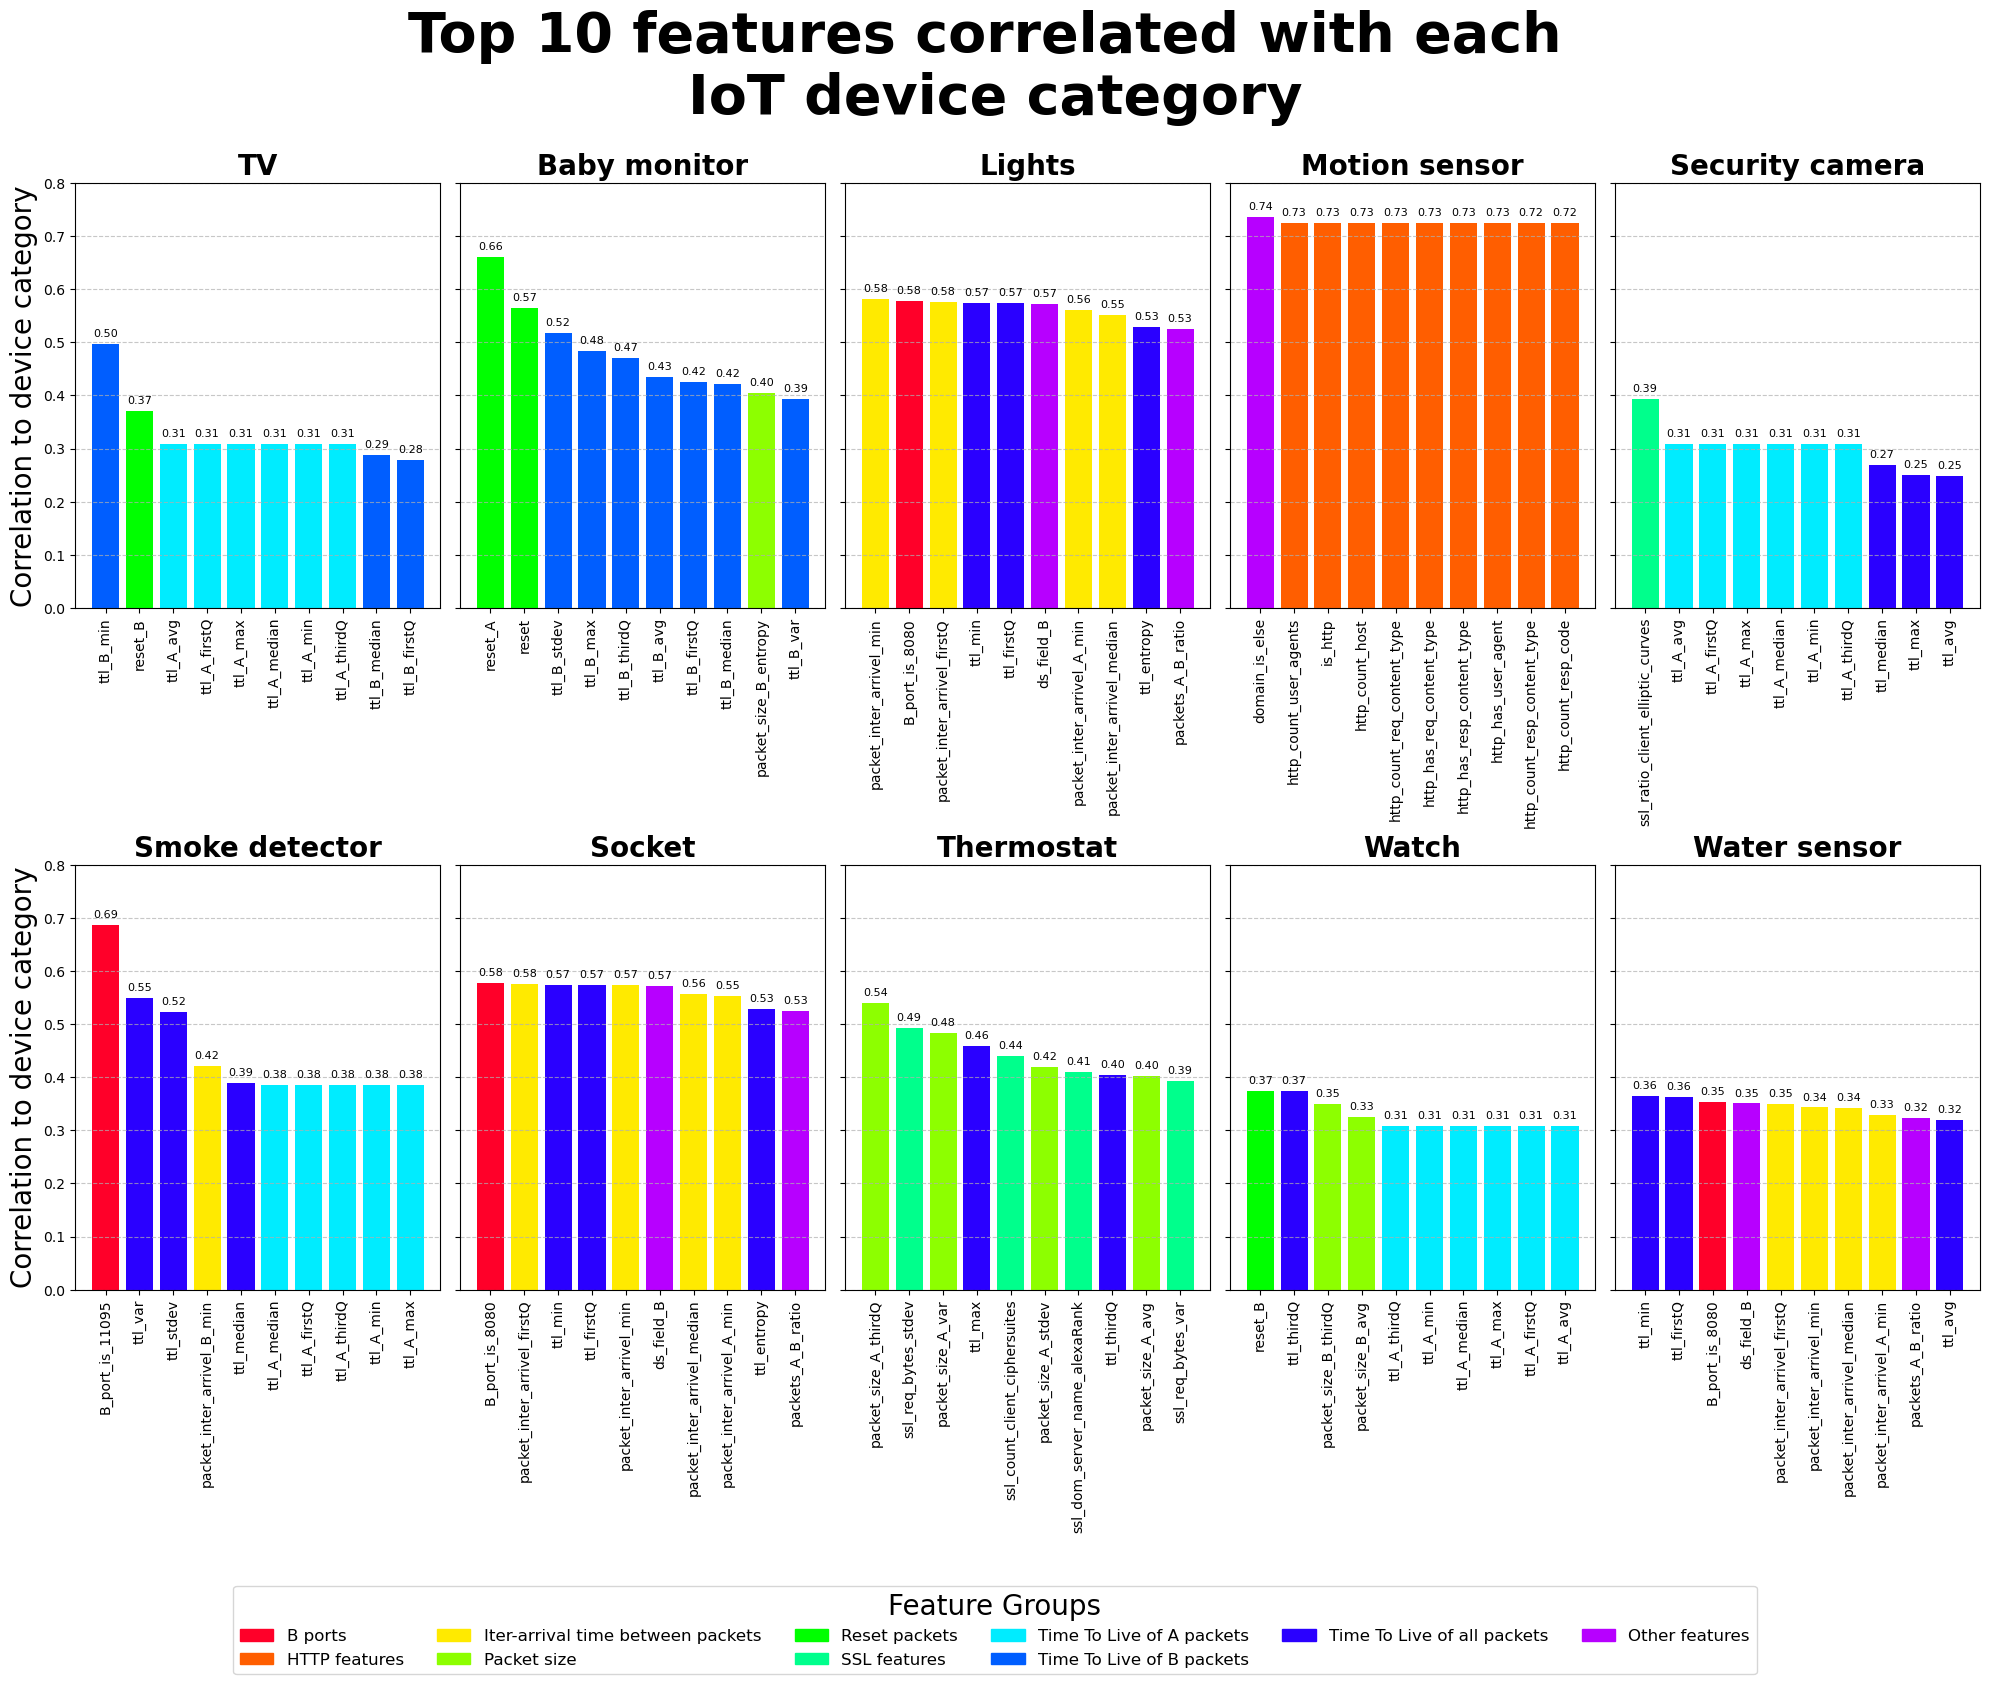

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 16), constrained_layout=False)
axes = axes.flatten()

for i, category in enumerate(device_categories):
    top_corr = corr_per_deviceCategory_top10_dict[category]
    
    ax = axes[i]
    
    #colors = [cmap_features_perDeviceCategory[category][feature] for feature in top_corr]
    colors = [cmap_features_perDeviceCategory[category][feature] for feature in top_corr.index]
    bars = ax.bar(range(len(top_corr)), top_corr.values, color=colors)
    #bars = ax.bar(range(len(top_corr)), top_corr.values(), color=colors)
    
    # value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # title of the current subplot
    ax.set_title(f'{device_category_names[category]}', fontsize=20, fontweight='bold')

    # x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr.index, rotation=90)
    if i % 5 == 0:  # only leftmost plots in each row get a y-label    
        ax.set_ylabel('Correlation to device category', size=20)
    else:   # plots that are not the leftmost ones in each row get no y-label or y-tick labels
        ax.set_yticklabels([])
    
    ax.set_ylim(0, 0.8)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# plot color legend
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap_feature_groups[group]) for group in features_mostCorrelated_groups.keys()]
legend_labels = [feature_group_names.get(group, group.replace('_', ' ').title()) 
                for group in features_mostCorrelated_groups.keys()]
fig.legend(handles, legend_labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0), 
           fontsize=12, frameon=True, title='Feature Groups', title_fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=1)  # space covered by plots
plt.subplots_adjust(bottom=0.18)                # adjust the bottom margin to make room for the legend

# plot title
plt.suptitle('Top 10 features correlated with each \nIoT device category', fontsize=40, fontweight='bold')
plt.show()

<h2>Inspecting feature colinearity</h2>

<h3>Grouping all features</h3>

In [23]:
features = data_X.columns.tolist()

In [24]:
print(features)

['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio', 'bytes_B', 'ds_field_A', 'ds_field_B', 'duration', 'http_GET', 'http_POST', 'http_bytes_avg', 'http_bytes_entropy', 'http_bytes_firstQ', 'http_bytes_max', 'http_bytes_median', 'http_bytes_min', 'http_bytes_stdev', 'http_bytes_sum', 'http_bytes_thirdQ', 'http_bytes_var', 'http_cookie_count', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', 'http_cookie_values_min', 'http_cookie_values_stdev', 'http_cookie_values_sum', 'http_cookie_values_thirdQ', 'http_cookie_values_var', 'http_count_host', 'http_count_req_content_type', 'http_count_resp_code', 'http_count_resp_content_type', 'http_count_transactions', 'http_count_user_agents', 'http_dom_host_alexaRank', 'http_dom_resp_code', 'http_has_location', 'http_has_referrer', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'http_inter_arrivel_avg', 'http_inte

In [25]:
feature_groups = {
    'B_port': [feature for feature in features if feature.startswith('B_port') or ('B' in feature and 'port' in feature)],
    'domain': [feature for feature in features if feature.startswith('domain_')],
    'http_bytes': [feature for feature in features if feature.startswith('http_bytes_')],
    'http_cookie': [feature for feature in features if feature.startswith('http_cookie_')],
    'http_count': [feature for feature in features if feature.startswith('http_count_')],
    'http_inter': [feature for feature in features if feature.startswith('http_inter_')],
    'http_req': [feature for feature in features if feature.startswith('http_req_')],
    'http_resp': [feature for feature in features if feature.startswith('http_resp_')],
    'http_time': [feature for feature in features if feature.startswith('http_time_')],
    'http_type': [feature for feature in features if (('http' in feature) and feature.startswith('is_'))],
    'http_other': [],
    'num_packets': [feature for feature in features if feature.startswith('packets')],
    'packet_inter_arrivel_A': [feature for feature in features if feature.startswith('packet_inter_arrivel_A_')],
    'packet_inter_arrivel_B': [feature for feature in features if feature.startswith('packet_inter_arrivel_B_')],
    'packet_inter_arrivel_all': [feature for feature in features if feature.startswith('packet_inter_arrivel_') and not feature.startswith('packet_inter_arrivel_A_') and not feature.startswith('packet_inter_arrivel_B_')],
    'packet_size_A': [feature for feature in features if feature.startswith('packet_size_A_')],
    'packet_size_B': [feature for feature in features if feature.startswith('packet_size_B_')],
    'packet_size_all': [feature for feature in features if feature.startswith('packet_size_') and not feature.startswith('packet_size_A_') and not feature.startswith('packet_size_B_')],
    'ssl_count': [feature for feature in features if feature.startswith('ssl_count_')],
    'ssl_handshake': [feature for feature in features if feature.startswith('ssl_handshake_')],
    'ssl_req': [feature for feature in features if feature.startswith('ssl_req_')],
    'ssl_resp': [feature for feature in features if feature.startswith('ssl_resp_')],
    'subdomain': [feature for feature in features if feature.startswith('subdomain_')],
    'suffix': [feature for feature in features if feature.startswith('suffix_')],
    'tcp_analysis': [feature for feature in features if feature.startswith('tcp_analysis_')],
    'ttl_A': [feature for feature in features if feature.startswith('ttl_A_')],
    'ttl_B': [feature for feature in features if feature.startswith('ttl_B_')],
    'ttl_all': [feature for feature in features if feature.startswith('ttl_') and not feature.startswith('ttl_A_') and not feature.startswith('ttl_B_')],
    'other': []
}
for feature in features:
    if (
        feature.startswith('http_') 
        and (not feature in feature_groups['http_bytes'])
        and (not feature in feature_groups['http_cookie'])
        and (not feature in feature_groups['http_count'])
        and (not feature in feature_groups['http_inter'])
        and (not feature in feature_groups['http_req'])
        and (not feature in feature_groups['http_resp'])
        and (not feature in feature_groups['http_time'])
        and (not feature in feature_groups['http_type'])
    ): 
        feature_groups['http_other'].append(feature)
features_not_in_other = []
for key, value in feature_groups.items():
    features_not_in_other.extend(value)
for feature in features:
    if feature not in features_not_in_other:
        feature_groups['other'].append(feature)
print(feature_groups)

{'B_port': ['B_is_system_port', 'B_is_user_port', 'B_is_dynamic_and_or_private_port', 'B_port_is_11095', 'B_port_is_1900', 'B_port_is_5222', 'B_port_is_5223', 'B_port_is_5228', 'B_port_is_54975', 'B_port_is_80', 'B_port_is_8080', 'B_port_is_8280', 'B_port_is_9543', 'B_port_is_else'], 'domain': ['domain_is_dlink', 'domain_is_else', 'domain_is_epicurious', 'domain_is_google', 'domain_is_hp', 'domain_is_hpeprint', 'domain_is_livecdn', 'domain_is_mako', 'domain_is_proteussensor', 'domain_is_samsung', 'domain_is_unresolved'], 'http_bytes': ['http_bytes_avg', 'http_bytes_entropy', 'http_bytes_firstQ', 'http_bytes_max', 'http_bytes_median', 'http_bytes_min', 'http_bytes_stdev', 'http_bytes_sum', 'http_bytes_thirdQ', 'http_bytes_var'], 'http_cookie': ['http_cookie_count', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', 'http_cookie_values_min', 'http_cookie_values_stdev', 'http_cookie_values_sum', 'http

In [26]:
feature_correlations_per_group = {
    key: pd.DataFrame() for key in feature_groups.keys()
}
for key in feature_correlations_per_group.keys():
    tempdf_lowColinearity = pd.DataFrame(index=feature_groups[key], columns=feature_groups[key])
    for row in feature_correlations.iterrows():
        if row[0] in feature_groups[key]:
            tempdf_lowColinearity[row[0]] = tempdf_lowColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
    feature_correlations_per_group[key] = tempdf_lowColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')
print(feature_correlations_per_group)

{'B_port':                                   B_is_system_port  B_is_user_port  \
B_is_system_port                          1.000000       -0.997877   
B_is_user_port                           -0.997877        1.000000   
B_is_dynamic_and_or_private_port         -0.035773       -0.029394   
B_port_is_11095                          -0.259749        0.260302   
B_port_is_1900                           -0.071660        0.071812   
B_port_is_5228                           -0.087858        0.088045   
B_port_is_80                              0.285371       -0.284765   
B_port_is_8080                           -0.655009        0.656403   
B_port_is_else                            0.435297       -0.439088   

                                  B_is_dynamic_and_or_private_port  \
B_is_system_port                                         -0.035773   
B_is_user_port                                           -0.029394   
B_is_dynamic_and_or_private_port                          1.000000   
B_port_i

In [27]:
feature_group_names = {
    'B_port': 'B packets destination port',
    'domain': 'Common domains',
    'http_bytes': 'HTTP bytes',
    'http_cookie': 'HTTP cookies',
    'http_count': 'HTTP packet count',
    'http_inter': 'Time between HTTP requests',
    'http_req': 'Number of bytes of HTTP requests',
    'http_resp': 'Number of bytes of HTTP responses',
    'http_time': 'HTTP date header',
    'http_type': 'HTTP request type',
    'http_other': 'Other HTTP features',
    'num_packets': 'Overall number of packets',
    'packet_inter_arrivel_A': 'Inter-arrival time of A packets',
    'packet_inter_arrivel_B': 'Inter-arrival time of B packets',
    'packet_inter_arrivel_all': 'Inter-arrival time of all packets',
    'packet_size_A': 'Packet size of A packets',
    'packet_size_B': 'Packet size of B packets',
    'packet_size_all': 'Packet size of all packets',
    'ssl_count': 'Number of SSL packets',
    'ssl_handshake': 'SSL handshake duration',
    'ssl_req': 'Number of bytes of SSL requests',
    'ssl_resp': 'Number of bytes of SSL responses',
    'subdomain': 'Common subdomains',
    'suffix': 'Common suffixes',
    'tcp_analysis': 'TCP connection status',
    'ttl_A': 'Time To Live of A packets',
    'ttl_B': 'Time To Live of B packets',
    'ttl_all': 'Time To Live of all packets',
    'other': 'Other features'
}

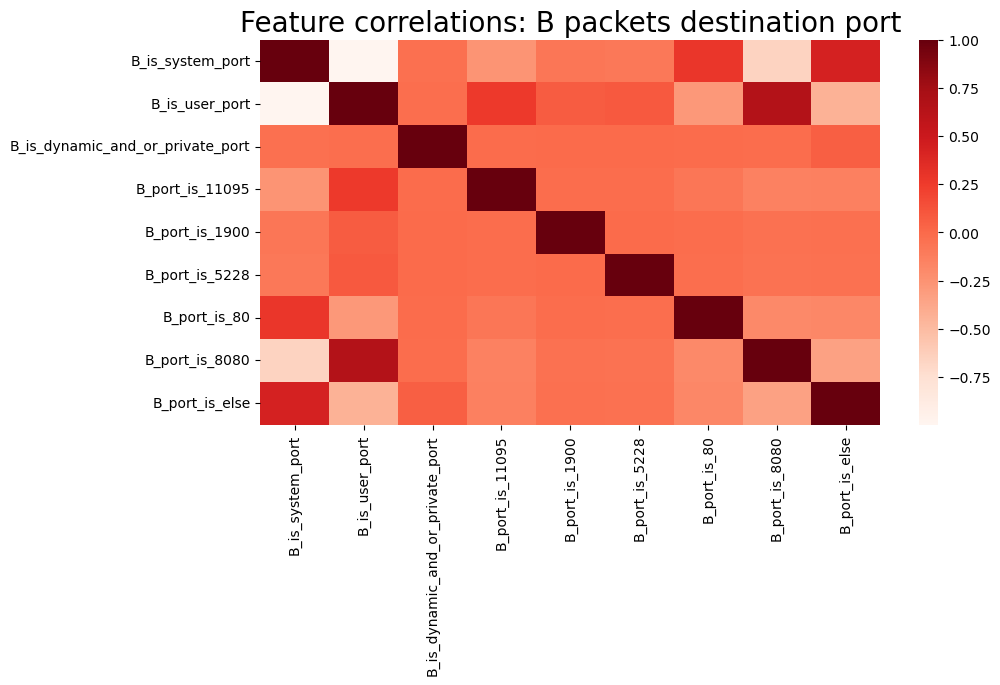

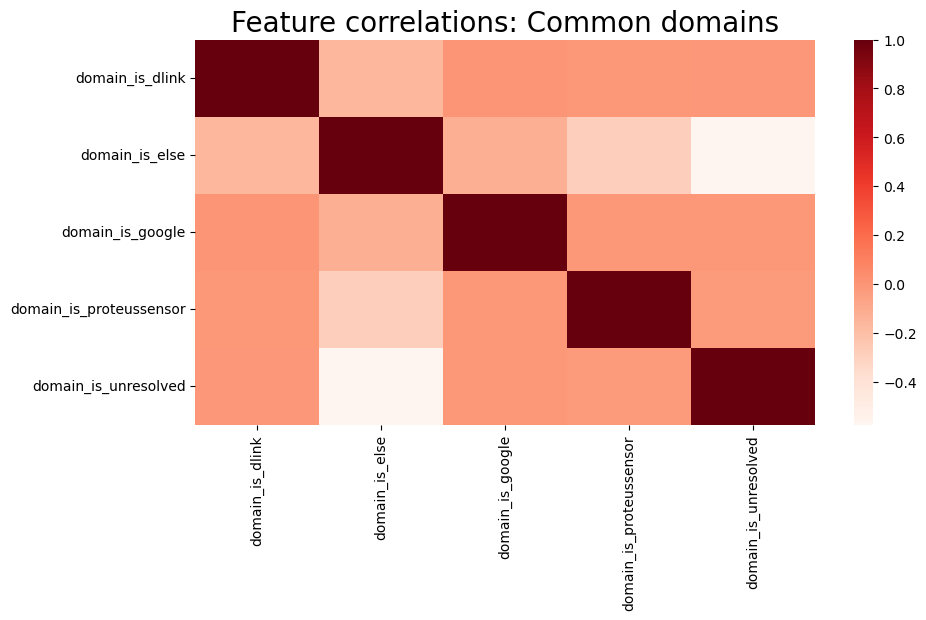

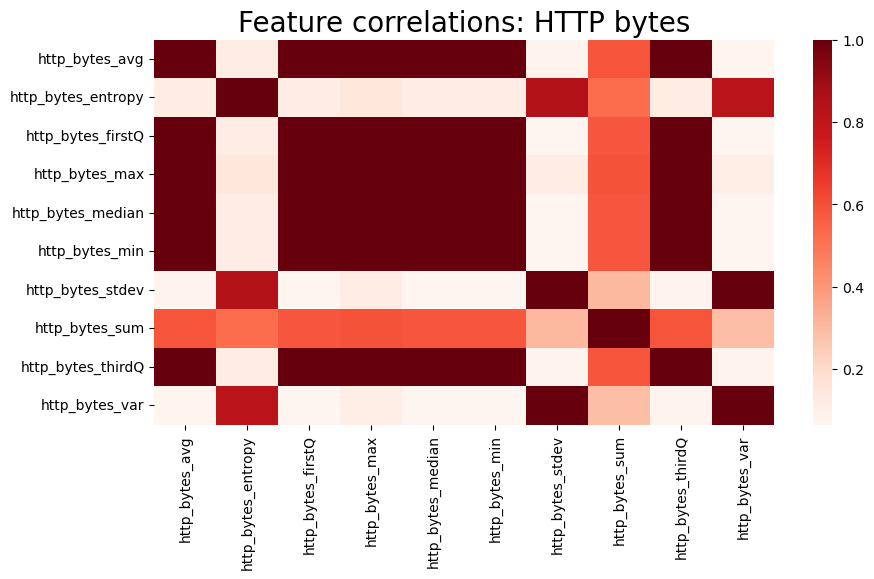

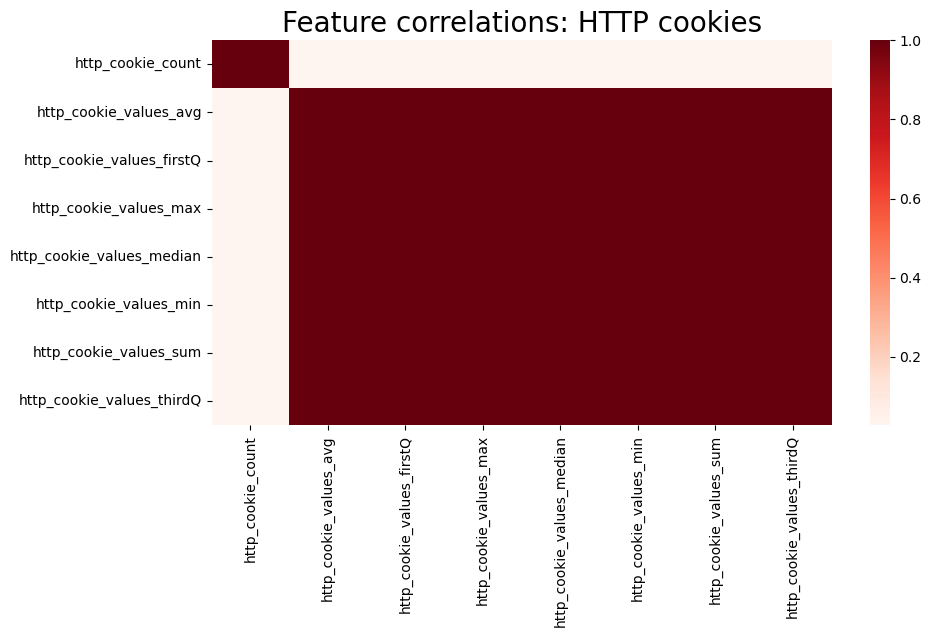

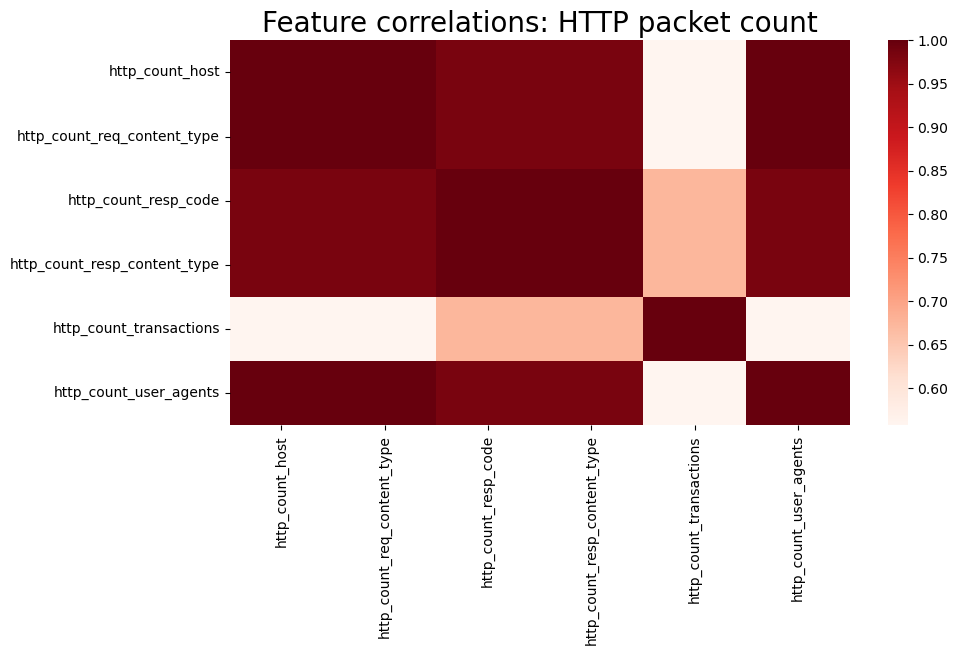

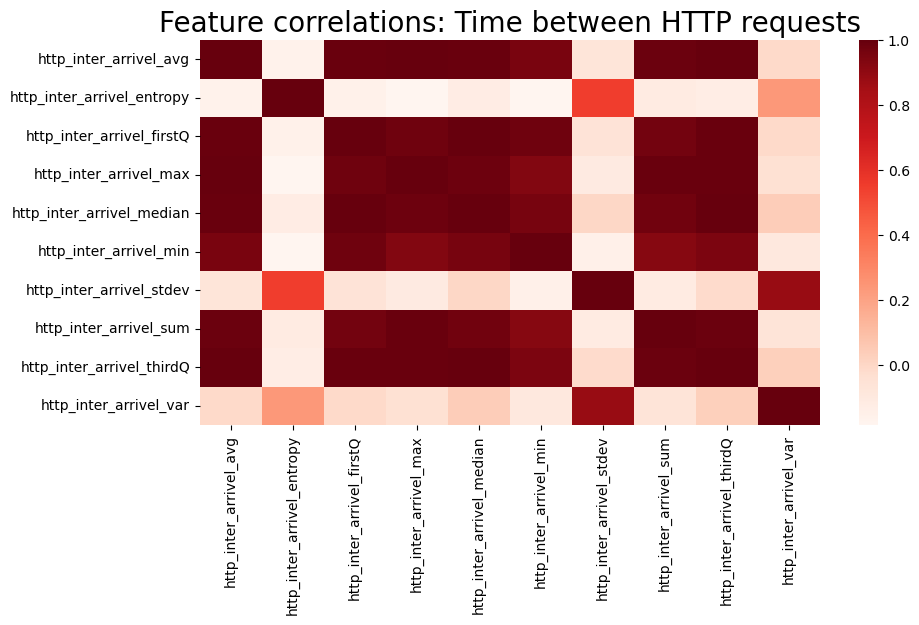

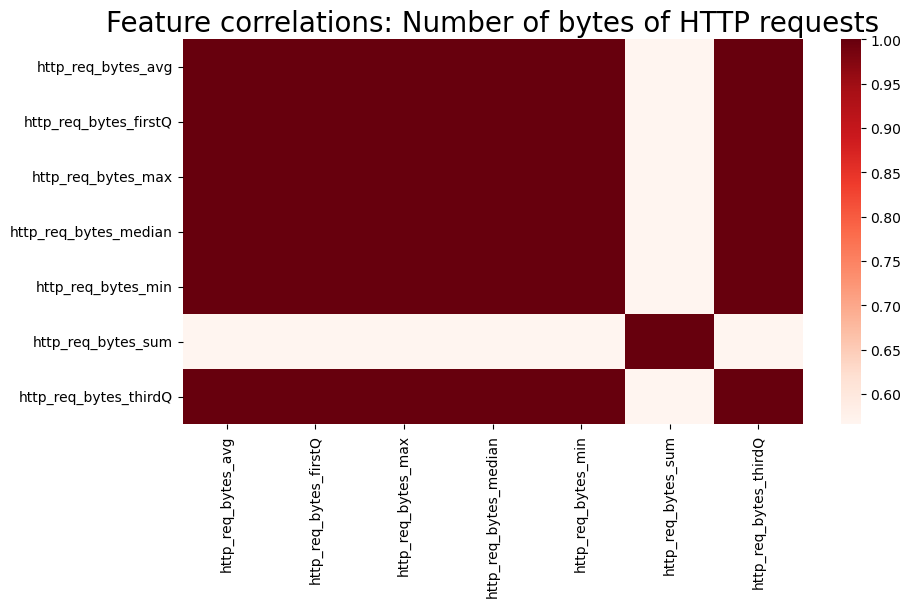

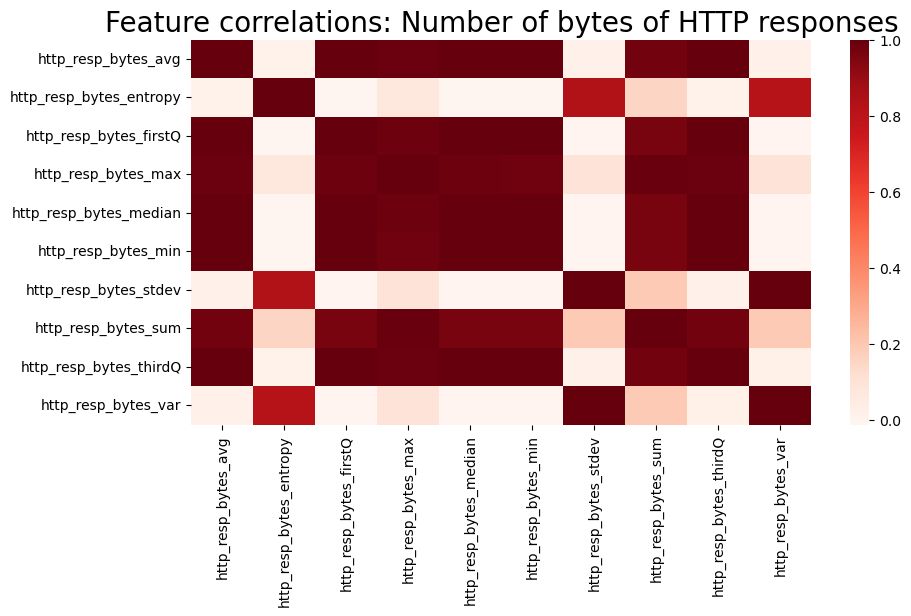

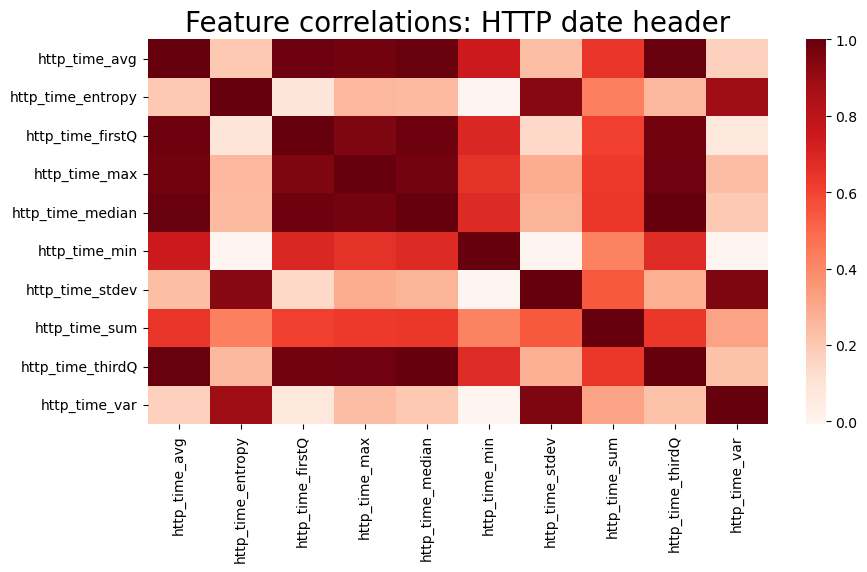

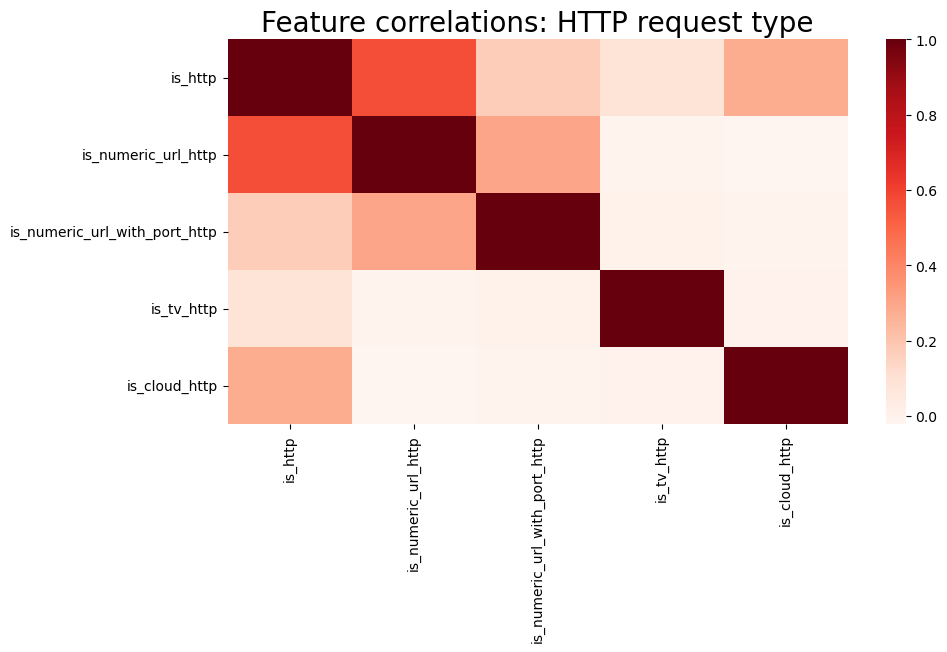

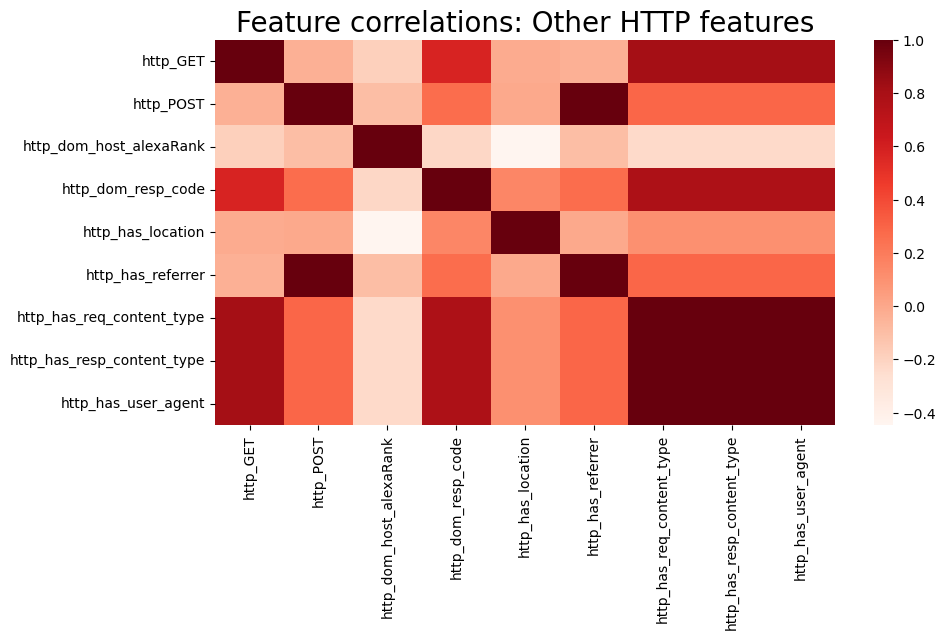

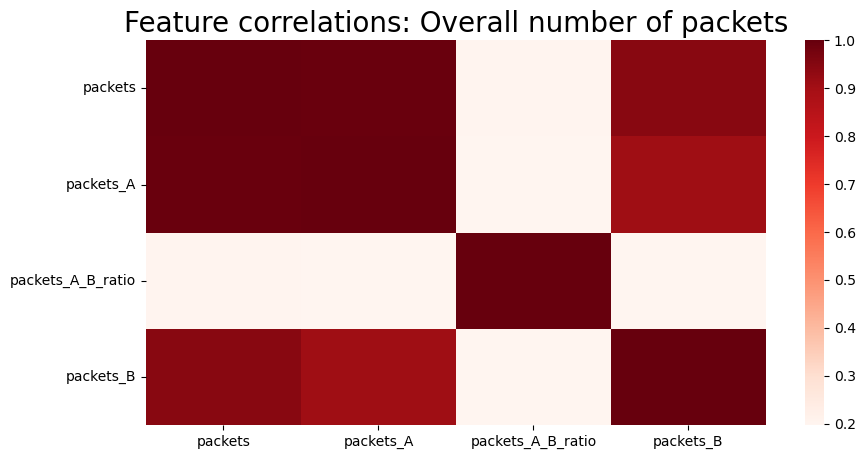

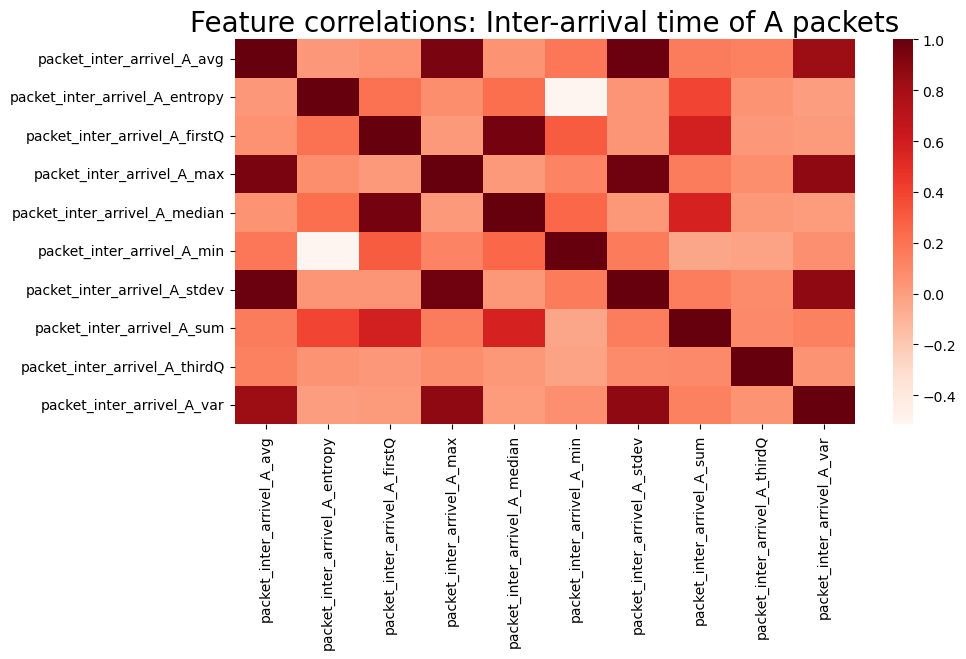

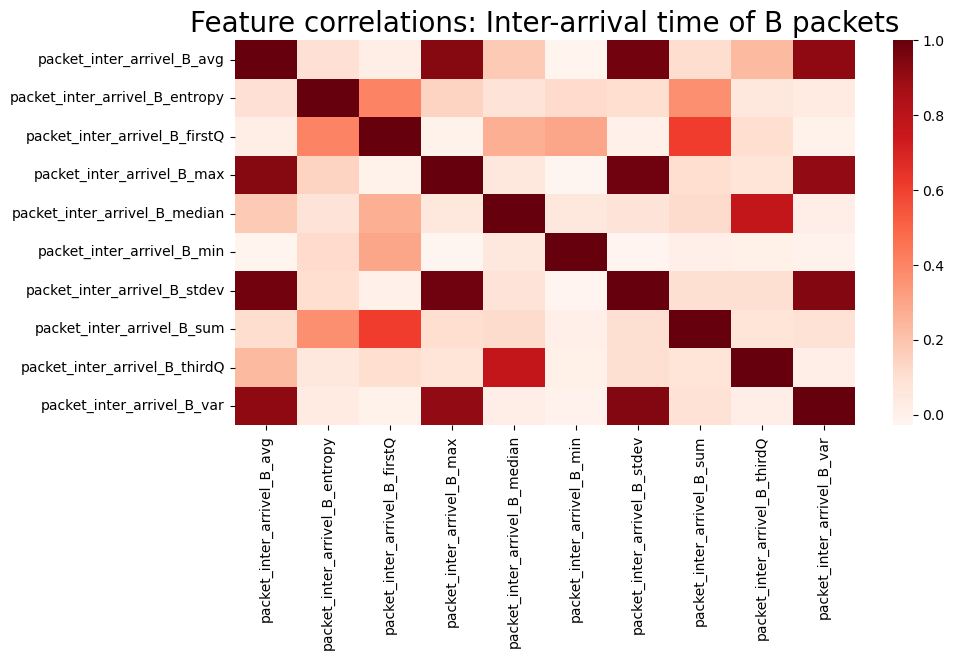

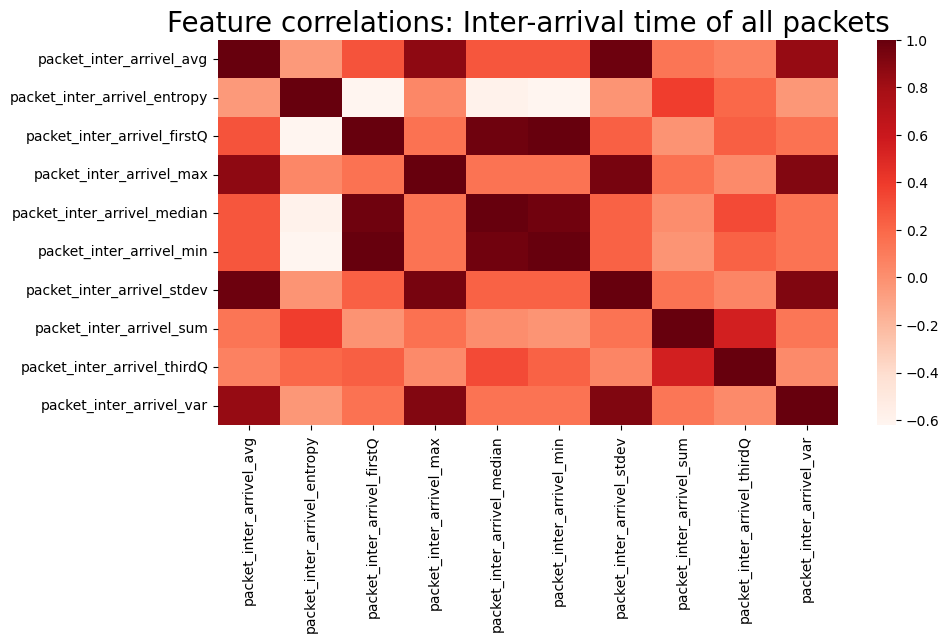

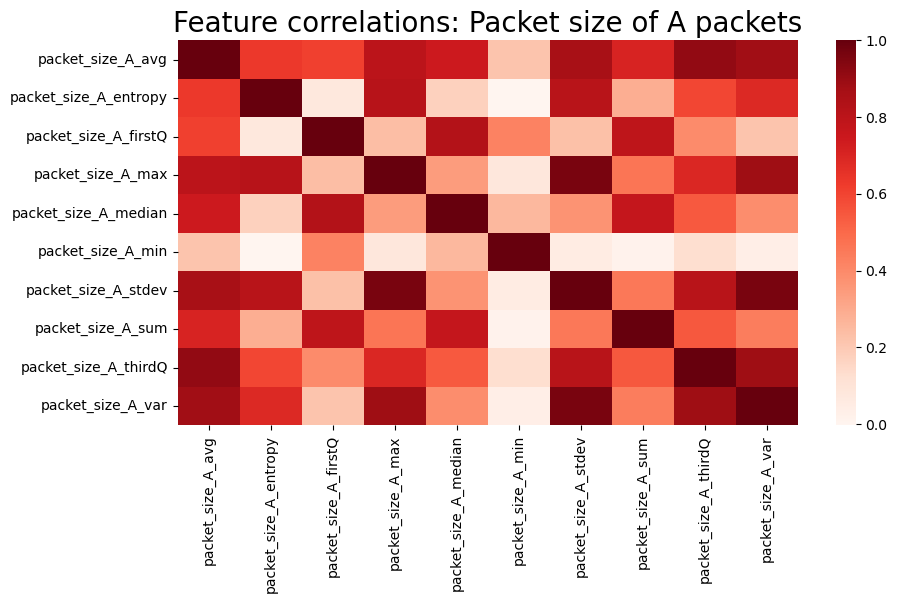

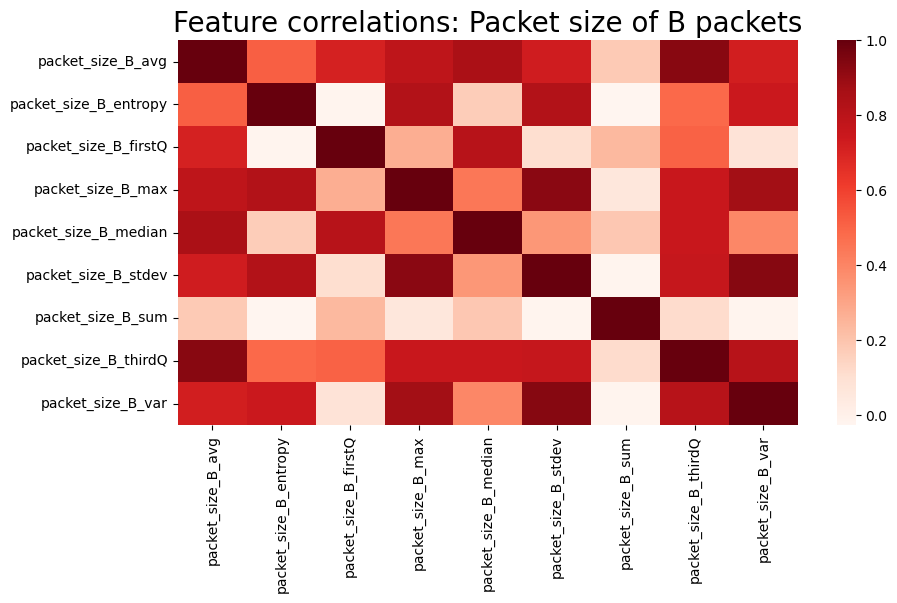

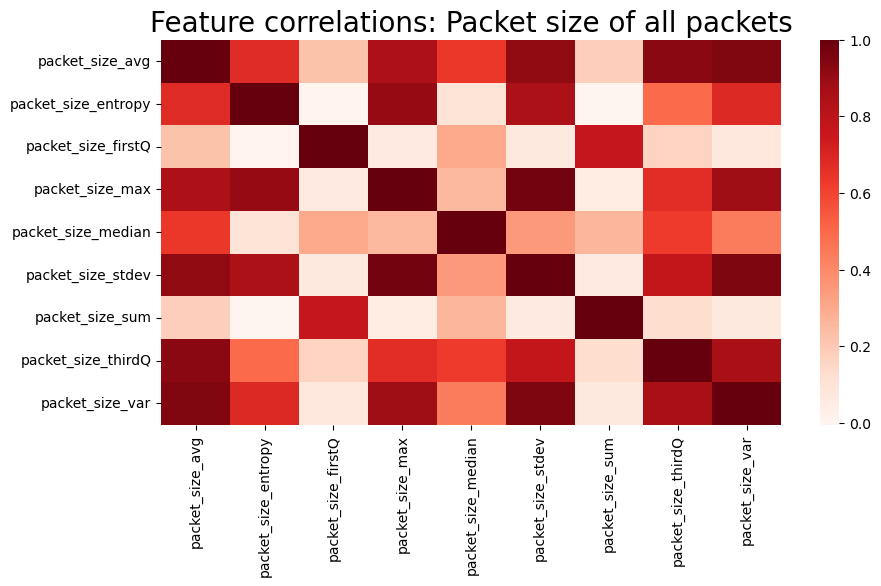

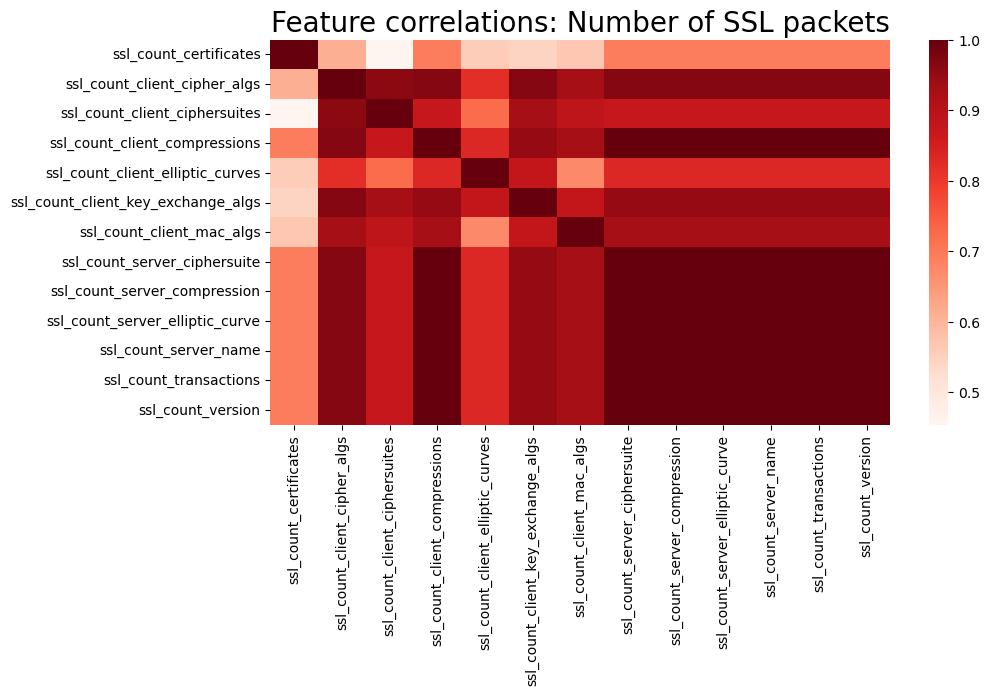

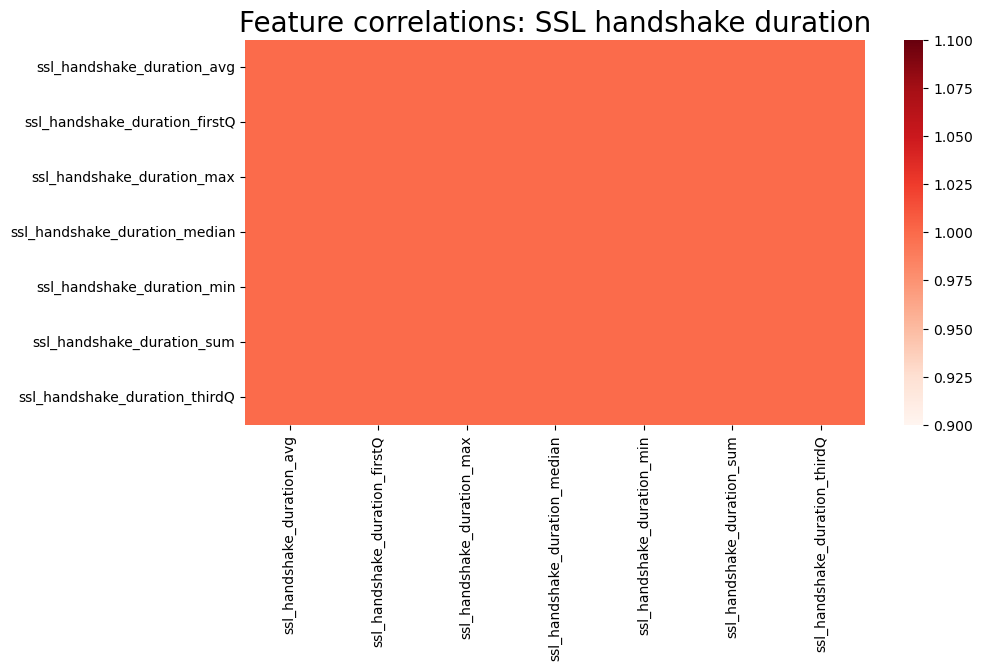

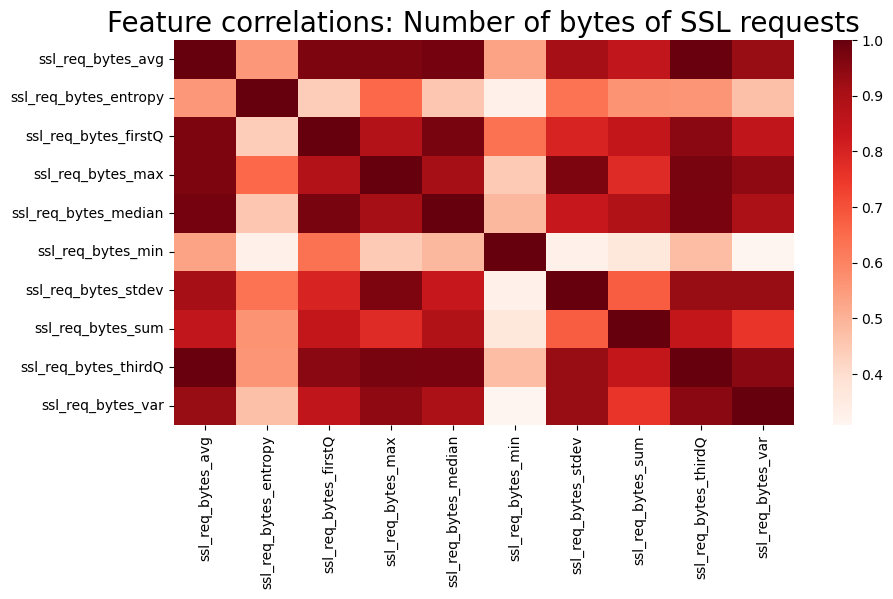

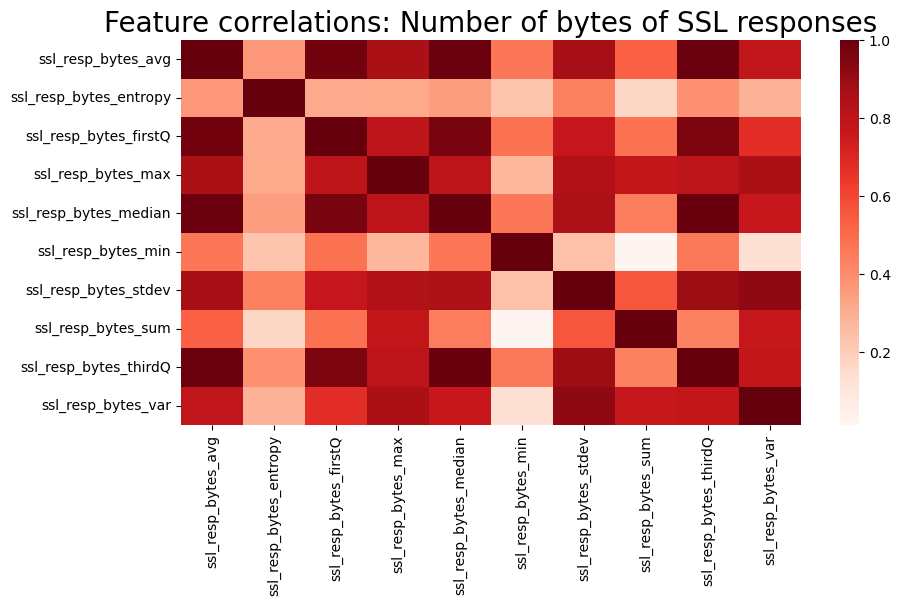

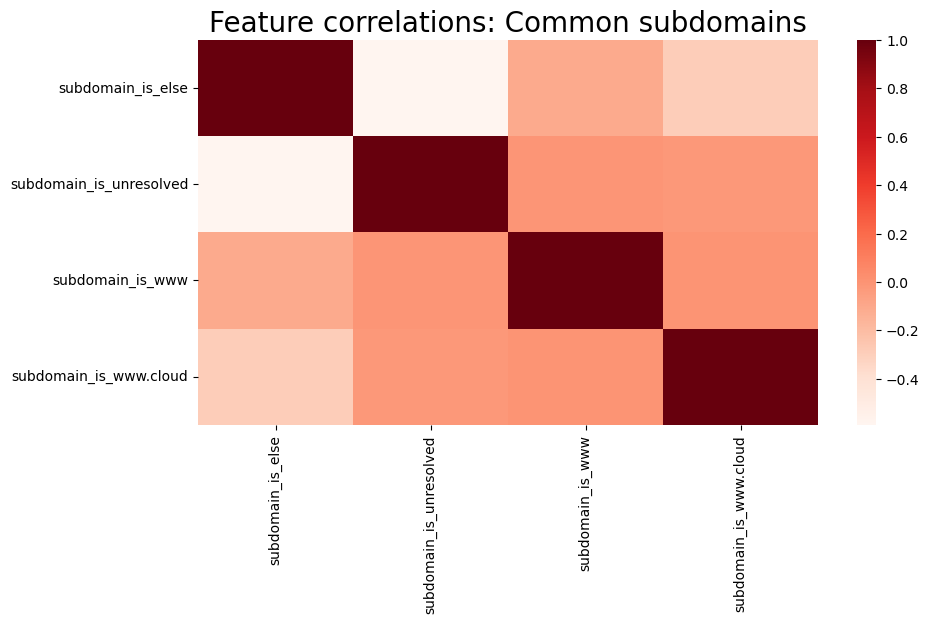

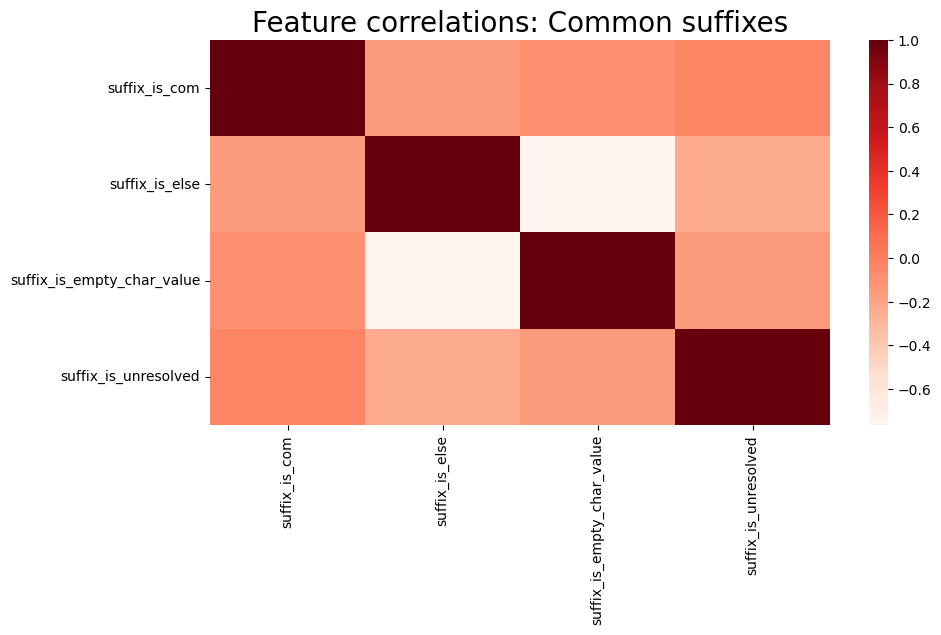

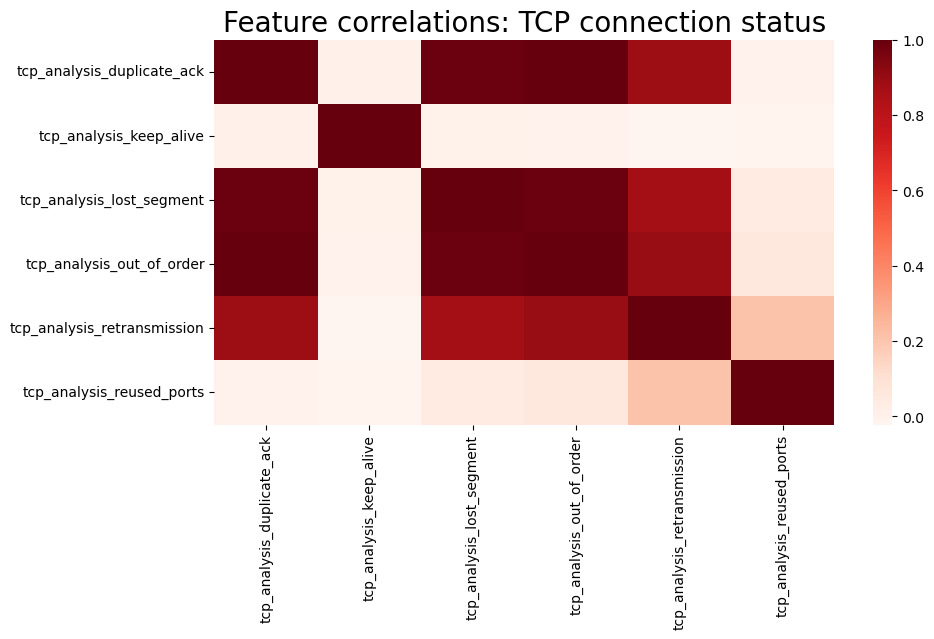

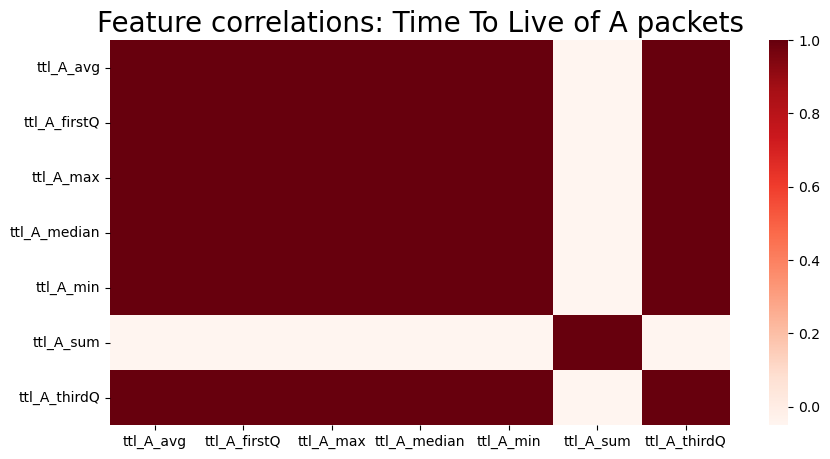

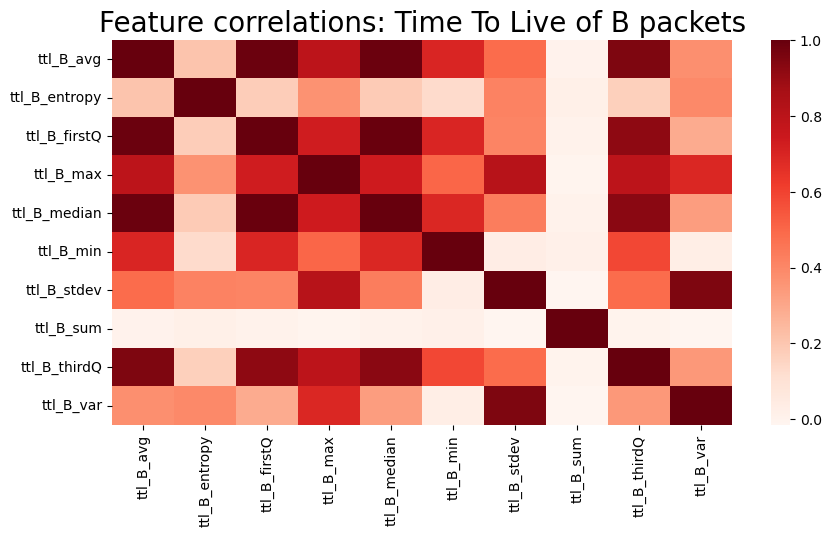

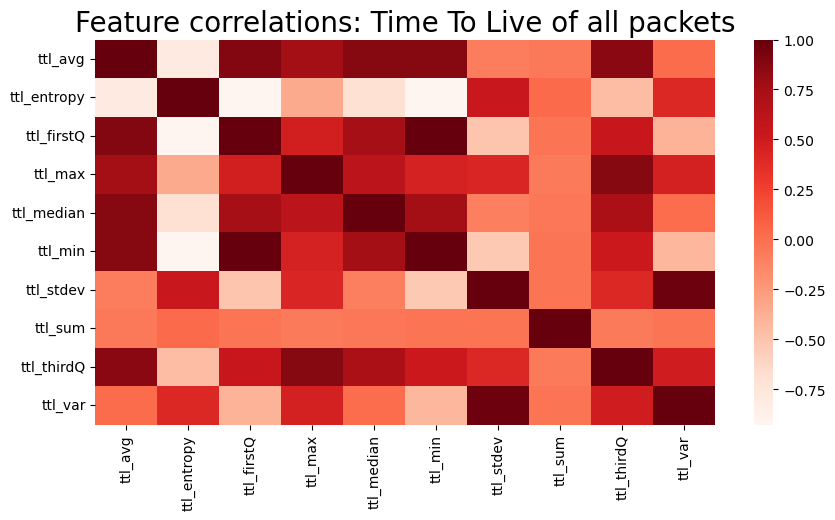

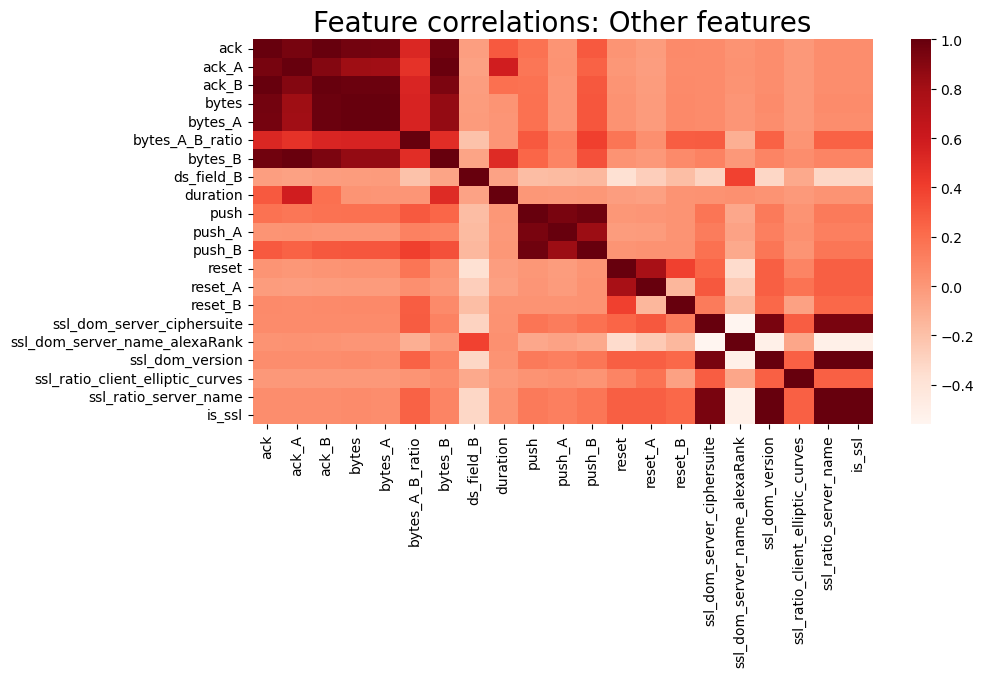

In [28]:
# create a correlation matrix per element of feature_groups
for key in feature_correlations_per_group.keys():
    plt.figure(figsize=(10, 5))
    sns.heatmap(data=feature_correlations_per_group[key], cmap='Reds')
    plt.title(f"Feature correlations: {feature_group_names[key]}", fontsize = 20)
    plt.show()

<h3>Choosing low-colinearity features per device category</h3>

In [29]:
# making a dictionary to make it easier to work with the data
corr_per_deviceCategory_dict = {}
for i, value in enumerate(corr_per_deviceCategory):
    corr_per_deviceCategory_dict[device_categories[i]] = {corr_per_deviceCategory[i].index[j]: v for j, v in enumerate(value)}

In [30]:
print(corr_per_deviceCategory_dict)

{'TV': {'ttl_B_min': 0.4960747218881487, 'reset_B': 0.37042371106026345, 'ttl_A_avg': 0.30853765772929354, 'ttl_A_firstQ': 0.30853765772929354, 'ttl_A_max': 0.30853765772929354, 'ttl_A_median': 0.30853765772929354, 'ttl_A_min': 0.30853765772929354, 'ttl_A_thirdQ': 0.30853765772929354, 'ttl_B_median': 0.2872173326154597, 'ttl_B_firstQ': 0.27823140599800156, 'ttl_B_avg': 0.27817730276489794, 'http_resp_bytes_min': 0.25903389708872354, 'http_resp_bytes_firstQ': 0.25892346001751787, 'http_resp_bytes_median': 0.2588068148221234, 'http_resp_bytes_avg': 0.2578488334500503, 'http_resp_bytes_thirdQ': 0.2576828696268809, 'http_resp_bytes_max': 0.25181266510234, 'ssl_count_client_mac_algs': 0.24988736005409207, 'http_resp_bytes_sum': 0.24517112276634187, 'reset': 0.24405954778180838, 'packet_inter_arrivel_median': 0.23877127987321423, 'ttl_max': 0.23504670951846823, 'ttl_B_thirdQ': 0.22487800978605685, 'packet_inter_arrivel_A_min': 0.22477634437853602, 'ttl_avg': 0.21976148297511489, 'B_is_system

In [31]:
# getting the top 10 features for each device category, but only if they are not intercorrelated with the already selected features
corr_per_deviceCategory_top10_lowColinearity = {category: {} for category in device_categories}
for category in device_categories:
    print('='*40)
    print(category)
    print("Correlations: ", corr_per_deviceCategory_dict[category])
    print('='*20)
    for feature in corr_per_deviceCategory_dict[category].keys():
        if len(corr_per_deviceCategory_top10_lowColinearity[category]) >= 10: break
        print('-'*20)
        print(feature)
        currentFeature_isIntercorrelated = False
        for feature_alreadyInTop10 in corr_per_deviceCategory_top10_lowColinearity[category].keys():
            if feature_correlations[feature][feature_alreadyInTop10] > 0.7:
                print(f"Feature {feature} is intercorrelated with {feature_alreadyInTop10}: {feature_correlations[feature][feature_alreadyInTop10]}")
                currentFeature_isIntercorrelated = True
                break
        if not currentFeature_isIntercorrelated:
            corr_per_deviceCategory_top10_lowColinearity[category][feature] = corr_per_deviceCategory_dict[category][feature]
            print(f"Feature {feature} added")
    print('='*20)
    print(category, " finished")
    print(corr_per_deviceCategory_top10_lowColinearity[category])
print(corr_per_deviceCategory_top10_lowColinearity)

TV
Correlations:  {'ttl_B_min': 0.4960747218881487, 'reset_B': 0.37042371106026345, 'ttl_A_avg': 0.30853765772929354, 'ttl_A_firstQ': 0.30853765772929354, 'ttl_A_max': 0.30853765772929354, 'ttl_A_median': 0.30853765772929354, 'ttl_A_min': 0.30853765772929354, 'ttl_A_thirdQ': 0.30853765772929354, 'ttl_B_median': 0.2872173326154597, 'ttl_B_firstQ': 0.27823140599800156, 'ttl_B_avg': 0.27817730276489794, 'http_resp_bytes_min': 0.25903389708872354, 'http_resp_bytes_firstQ': 0.25892346001751787, 'http_resp_bytes_median': 0.2588068148221234, 'http_resp_bytes_avg': 0.2578488334500503, 'http_resp_bytes_thirdQ': 0.2576828696268809, 'http_resp_bytes_max': 0.25181266510234, 'ssl_count_client_mac_algs': 0.24988736005409207, 'http_resp_bytes_sum': 0.24517112276634187, 'reset': 0.24405954778180838, 'packet_inter_arrivel_median': 0.23877127987321423, 'ttl_max': 0.23504670951846823, 'ttl_B_thirdQ': 0.22487800978605685, 'packet_inter_arrivel_A_min': 0.22477634437853602, 'ttl_avg': 0.21976148297511489, '

In [32]:
# dataframe to create correlation matrices per element of feature_groups
correlation_lowColinearityFeatures = {
    device_category: pd.DataFrame() for device_category in device_categories
}
correlation_highColinearityFeatures = {
    device_category: pd.DataFrame() for device_category in device_categories
}
for device_category in device_categories:
    # lists of features in the top 10 of each device category
    currentCategory_highColinearityFeatures = []
    for feature in corr_per_deviceCategory_top10_dict[device_category].keys():
        currentCategory_highColinearityFeatures.append(feature)
    currentCategory_lowColinearityFeatures = list(corr_per_deviceCategory_top10_lowColinearity[device_category].keys())
    print('-'*40)
    print("High-colinearity features: ", currentCategory_highColinearityFeatures)
    print("Low-colinearity features: ", currentCategory_lowColinearityFeatures)
    # creating a dataframe with the correlations of the features in the top 10 of each device category
    tempdf_highColinearity = pd.DataFrame(index=currentCategory_highColinearityFeatures, columns=currentCategory_highColinearityFeatures)
    tempdf_lowColinearity = pd.DataFrame(index=currentCategory_lowColinearityFeatures, columns=currentCategory_lowColinearityFeatures)
    for row in feature_correlations.iterrows():
        if row[0] in currentCategory_highColinearityFeatures:
            tempdf_highColinearity[row[0]] = tempdf_highColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
        if row[0] in currentCategory_lowColinearityFeatures:
            tempdf_lowColinearity[row[0]] = tempdf_lowColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
    correlation_lowColinearityFeatures[device_category] = tempdf_lowColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')
    correlation_highColinearityFeatures[device_category] = tempdf_highColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')

----------------------------------------
High-colinearity features:  ['ttl_B_min', 'reset_B', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_median', 'ttl_B_firstQ']
Low-colinearity features:  ['ttl_B_min', 'reset_B', 'ttl_A_avg', 'ttl_B_median', 'http_resp_bytes_min', 'ssl_count_client_mac_algs', 'reset', 'ttl_max', 'B_is_system_port', 'packet_size_B_avg']
----------------------------------------
High-colinearity features:  ['reset_A', 'reset', 'ttl_B_stdev', 'ttl_B_max', 'ttl_B_thirdQ', 'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_median', 'packet_size_B_entropy', 'ttl_B_var']
Low-colinearity features:  ['reset_A', 'ttl_B_stdev', 'ttl_B_thirdQ', 'packet_size_B_entropy', 'ssl_count_client_elliptic_curves', 'B_is_system_port', 'B_is_user_port', 'ssl_req_bytes_entropy', 'ssl_resp_bytes_entropy', 'suffix_is_else']
----------------------------------------
High-colinearity features:  ['packet_inter_arrivel_min', 'B_port_is_8080', 'packet_inter_arrivel_

In [33]:
print(corr_per_deviceCategory_top10_lowColinearity)

{'TV': {'ttl_B_min': 0.4960747218881487, 'reset_B': 0.37042371106026345, 'ttl_A_avg': 0.30853765772929354, 'ttl_B_median': 0.2872173326154597, 'http_resp_bytes_min': 0.25903389708872354, 'ssl_count_client_mac_algs': 0.24988736005409207, 'reset': 0.24405954778180838, 'ttl_max': 0.23504670951846823, 'B_is_system_port': 0.2181969448611682, 'packet_size_B_avg': 0.21455906314414233}, 'baby_monitor': {'reset_A': 0.6609030807328219, 'ttl_B_stdev': 0.5179583228850314, 'ttl_B_thirdQ': 0.46985947519070353, 'packet_size_B_entropy': 0.40499028296022765, 'ssl_count_client_elliptic_curves': 0.3204864989037357, 'B_is_system_port': 0.31124352234560787, 'B_is_user_port': 0.31058263495405203, 'ssl_req_bytes_entropy': 0.30135274391937333, 'ssl_resp_bytes_entropy': 0.29936781954013736, 'suffix_is_else': 0.2962861291244709}, 'lights': {'packet_inter_arrivel_min': 0.5819647625405432, 'ttl_entropy': 0.5289179233255678, 'packet_size_entropy': 0.4113032204200658, 'packet_inter_arrivel_entropy': 0.3966650572244

In [34]:
features_mostCorrelated_lowColinearity = set()
for feature in corr_per_deviceCategory_top10_lowColinearity.keys():
    features_mostCorrelated_lowColinearity.update(corr_per_deviceCategory_top10_lowColinearity[feature].keys())
features_mostCorrelated_lowColinearity = list(features_mostCorrelated_lowColinearity)
# order elements of features alphabetically
features_mostCorrelated_lowColinearity.sort()
print(len(features_mostCorrelated_lowColinearity), " features.")
print(features_mostCorrelated_lowColinearity)

62  features.
['B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_5228', 'B_port_is_8080', 'bytes_A_B_ratio', 'domain_is_else', 'http_bytes_sum', 'http_count_user_agents', 'http_dom_resp_code', 'http_resp_bytes_min', 'http_resp_bytes_sum', 'http_time_max', 'http_time_min', 'packet_inter_arrivel_A_median', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_max', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_avg', 'packet_inter_arrivel_entropy', 'packet_inter_arrivel_min', 'packet_size_A_entropy', 'packet_size_A_thirdQ', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packet_size_entropy', 'packet_size_max', 'packets_A_B_ratio', 'push_A', 'reset', 'reset_A', 'reset_B', 'ssl_count_client_elliptic_curves', 'ssl_count_client_key_exchange_algs', 'ssl_count_client_mac_algs', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_entropy', 'ssl_req_bytes_min', 'ssl_resp_bytes_entropy', 'subdomain_is_www.cloud', 'suff

In [35]:
features_mostCorrelated_lowColinearity_groups = {
    'B_port': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('B_')],
    'http': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('http')],
    'packet_inter': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('packet_inter')],
    'packet_size': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('packet_size')],
    'reset': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('reset')],
    'ssl': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('ssl')],
    'suffix': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('suffix')],
    'ttl_A': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('ttl_A')],
    'ttl_B': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('ttl_B')],
    'ttl_all': [feature for feature in features_mostCorrelated_lowColinearity if feature.startswith('ttl_') and not feature.startswith('ttl_A') and not feature.startswith('ttl_B')],
    'other': []
}
features_not_in_other = []
for key, value in features_mostCorrelated_lowColinearity_groups.items():
    features_not_in_other.extend(value)
for feature in features_mostCorrelated_lowColinearity:
    if feature not in features_not_in_other:
        features_mostCorrelated_lowColinearity_groups['other'].append(feature)
print(features_mostCorrelated_lowColinearity_groups)

{'B_port': ['B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_5228', 'B_port_is_8080'], 'http': ['http_bytes_sum', 'http_count_user_agents', 'http_dom_resp_code', 'http_resp_bytes_min', 'http_resp_bytes_sum', 'http_time_max', 'http_time_min'], 'packet_inter': ['packet_inter_arrivel_A_median', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_max', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_avg', 'packet_inter_arrivel_entropy', 'packet_inter_arrivel_min'], 'packet_size': ['packet_size_A_entropy', 'packet_size_A_thirdQ', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packet_size_entropy', 'packet_size_max'], 'reset': ['reset', 'reset_A', 'reset_B'], 'ssl': ['ssl_count_client_elliptic_curves', 'ssl_count_client_key_exchange_algs', 'ssl_count_client_mac_algs', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_entropy', 'ssl_req_bytes_min', 'ssl_resp_bytes_entropy'], 'suffix': ['suffix_is_else', 'suffix

In [36]:
for key in features_mostCorrelated_lowColinearity_groups.keys():
    print(len(features_mostCorrelated_lowColinearity_groups[key]), "features in group ", key)
    print(features_mostCorrelated_lowColinearity_groups[key]) 

5 features in group  B_port
['B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_5228', 'B_port_is_8080']
7 features in group  http
['http_bytes_sum', 'http_count_user_agents', 'http_dom_resp_code', 'http_resp_bytes_min', 'http_resp_bytes_sum', 'http_time_max', 'http_time_min']
7 features in group  packet_inter
['packet_inter_arrivel_A_median', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_max', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_avg', 'packet_inter_arrivel_entropy', 'packet_inter_arrivel_min']
7 features in group  packet_size
['packet_size_A_entropy', 'packet_size_A_thirdQ', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packet_size_entropy', 'packet_size_max']
3 features in group  reset
['reset', 'reset_A', 'reset_B']
8 features in group  ssl
['ssl_count_client_elliptic_curves', 'ssl_count_client_key_exchange_algs', 'ssl_count_client_mac_algs', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_re

In [37]:
# number of device categories each feature is in the top 10 of
features_mostCorrelated_lowColinearity_prevalence = {feature: 0 for feature in features_mostCorrelated_lowColinearity}
# sum of the correlations of each feature with all device categories
features_mostCorrelated_lowColinearity_correlationSum = {feature: 0 for feature in features_mostCorrelated_lowColinearity}
for device_category in device_categories:
    for feature in corr_per_deviceCategory_top10_lowColinearity[device_category].keys():
        features_mostCorrelated_lowColinearity_prevalence[feature] += 1
        features_mostCorrelated_lowColinearity_correlationSum[feature] += corr_per_deviceCategory_top10_lowColinearity[device_category][feature]

In [38]:
sum = 0
for feature in features_mostCorrelated_lowColinearity_prevalence.keys():
    sum += features_mostCorrelated_lowColinearity_prevalence[feature]
print(sum, "features in total")

100 features in total


In [39]:
features_mostCorrelated_lowColinearity_analysis = pd.DataFrame(index=features_mostCorrelated_lowColinearity)
features_mostCorrelated_lowColinearity_analysis['prevalence'] = features_mostCorrelated_lowColinearity_prevalence.values()
features_mostCorrelated_lowColinearity_analysis['correlation_sum'] = features_mostCorrelated_lowColinearity_correlationSum.values()
features_mostCorrelated_lowColinearity_analysis['avg_correlation'] = features_mostCorrelated_lowColinearity_analysis['correlation_sum'] / features_mostCorrelated_lowColinearity_analysis['prevalence']
features_mostCorrelated_lowColinearity_analysis['group'] = features_mostCorrelated_lowColinearity_analysis.index.map(
    lambda x: next((group for group, features in features_mostCorrelated_lowColinearity_groups.items() if x in features), 'none')
)
print(features_mostCorrelated_lowColinearity_analysis)

                  prevalence  correlation_sum  avg_correlation    group
B_is_system_port           8         2.290649         0.286331   B_port
B_is_user_port             1         0.310583         0.310583   B_port
B_port_is_11095            1         0.687184         0.687184   B_port
B_port_is_5228             1         0.232434         0.232434   B_port
B_port_is_8080             1         0.577076         0.577076   B_port
...                      ...              ...              ...      ...
ttl_median                 1         0.389614         0.389614  ttl_all
ttl_min                    2         0.574091         0.287045  ttl_all
ttl_stdev                  4         1.100276         0.275069  ttl_all
ttl_thirdQ                 1         0.374031         0.374031  ttl_all
ttl_var                    1         0.550083         0.550083  ttl_all

[62 rows x 4 columns]


In [40]:
import plotly.express as px
fig_corr = px.sunburst(
    features_mostCorrelated_lowColinearity_analysis, 
    path=['group', features_mostCorrelated_lowColinearity_analysis.index], 
    values='correlation_sum',
    color='avg_correlation', color_continuous_scale='Blues',
    title='Feature importance'
    )
fig_corr.show()

In [42]:
cmap = matplotlib.colormaps['gist_rainbow']
cmap_feature_groups_lowCollinearity = {group: cmap(i / len(features_mostCorrelated_lowColinearity_groups.keys())) for i, group in enumerate(features_mostCorrelated_lowColinearity_groups.keys())}
cmap_features_lowCollinearity = {row[0]: cmap_feature_groups_lowCollinearity[row[1].group] for row in features_mostCorrelated_lowColinearity_analysis.iterrows()}
cmap_features_perDeviceCategory_lowCollinearity = {device_category: {feature: cmap_features_lowCollinearity[feature] for feature in features_mostCorrelated_lowColinearity} for device_category in device_categories}

In [ ]:
features_mostCorrelated_lowColinearity_analysis

,prevalence,correlation_sum,avg_correlation,group
B_is_system_port,8,2.290649,0.286331,B_port
B_is_user_port,1,0.310583,0.310583,B_port
B_port_is_11095,1,0.687184,0.687184,B_port
B_port_is_5228,1,0.232434,0.232434,B_port
B_port_is_8080,1,0.577076,0.577076,B_port
...,...,...,...,...
ttl_median,1,0.389614,0.389614,ttl_all
ttl_min,2,0.574091,0.287045,ttl_all
ttl_stdev,4,1.100276,0.275069,ttl_all
ttl_thirdQ,1,0.374031,0.374031,ttl_all


In [45]:
len(cmap_feature_groups_lowCollinearity)

11

In [ ]:
len(features_mostCorrelated_lowColinearity_groups)

11

In [47]:
print(features_mostCorrelated_lowColinearity_groups)
print(len(cmap_features_lowCollinearity))

{'B_port': ['B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_5228', 'B_port_is_8080'], 'http': ['http_bytes_sum', 'http_count_user_agents', 'http_dom_resp_code', 'http_resp_bytes_min', 'http_resp_bytes_sum', 'http_time_max', 'http_time_min'], 'packet_inter': ['packet_inter_arrivel_A_median', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_max', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_avg', 'packet_inter_arrivel_entropy', 'packet_inter_arrivel_min'], 'packet_size': ['packet_size_A_entropy', 'packet_size_A_thirdQ', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packet_size_entropy', 'packet_size_max'], 'reset': ['reset', 'reset_A', 'reset_B'], 'ssl': ['ssl_count_client_elliptic_curves', 'ssl_count_client_key_exchange_algs', 'ssl_count_client_mac_algs', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_entropy', 'ssl_req_bytes_min', 'ssl_resp_bytes_entropy'], 'suffix': ['suffix_is_else', 'suffix

In [48]:
feature_group_names_lowColinearity = {
    'B port': 'B packets destination port',
    'http': 'HTTP features',
    'packet_inter': 'Inter-arrival time of packets',
    'packet_size': 'Packet size',
    'reset': 'Reset packets',
    'ssl': 'SSL features',
    'suffix': 'Common suffixes',
    'ttl_A': 'Time To Live of A packets',
    'ttl_B': 'Time To Live of B packets',
    'ttl_all': 'Time To Live of all packets',
    'other': 'Other features'
}

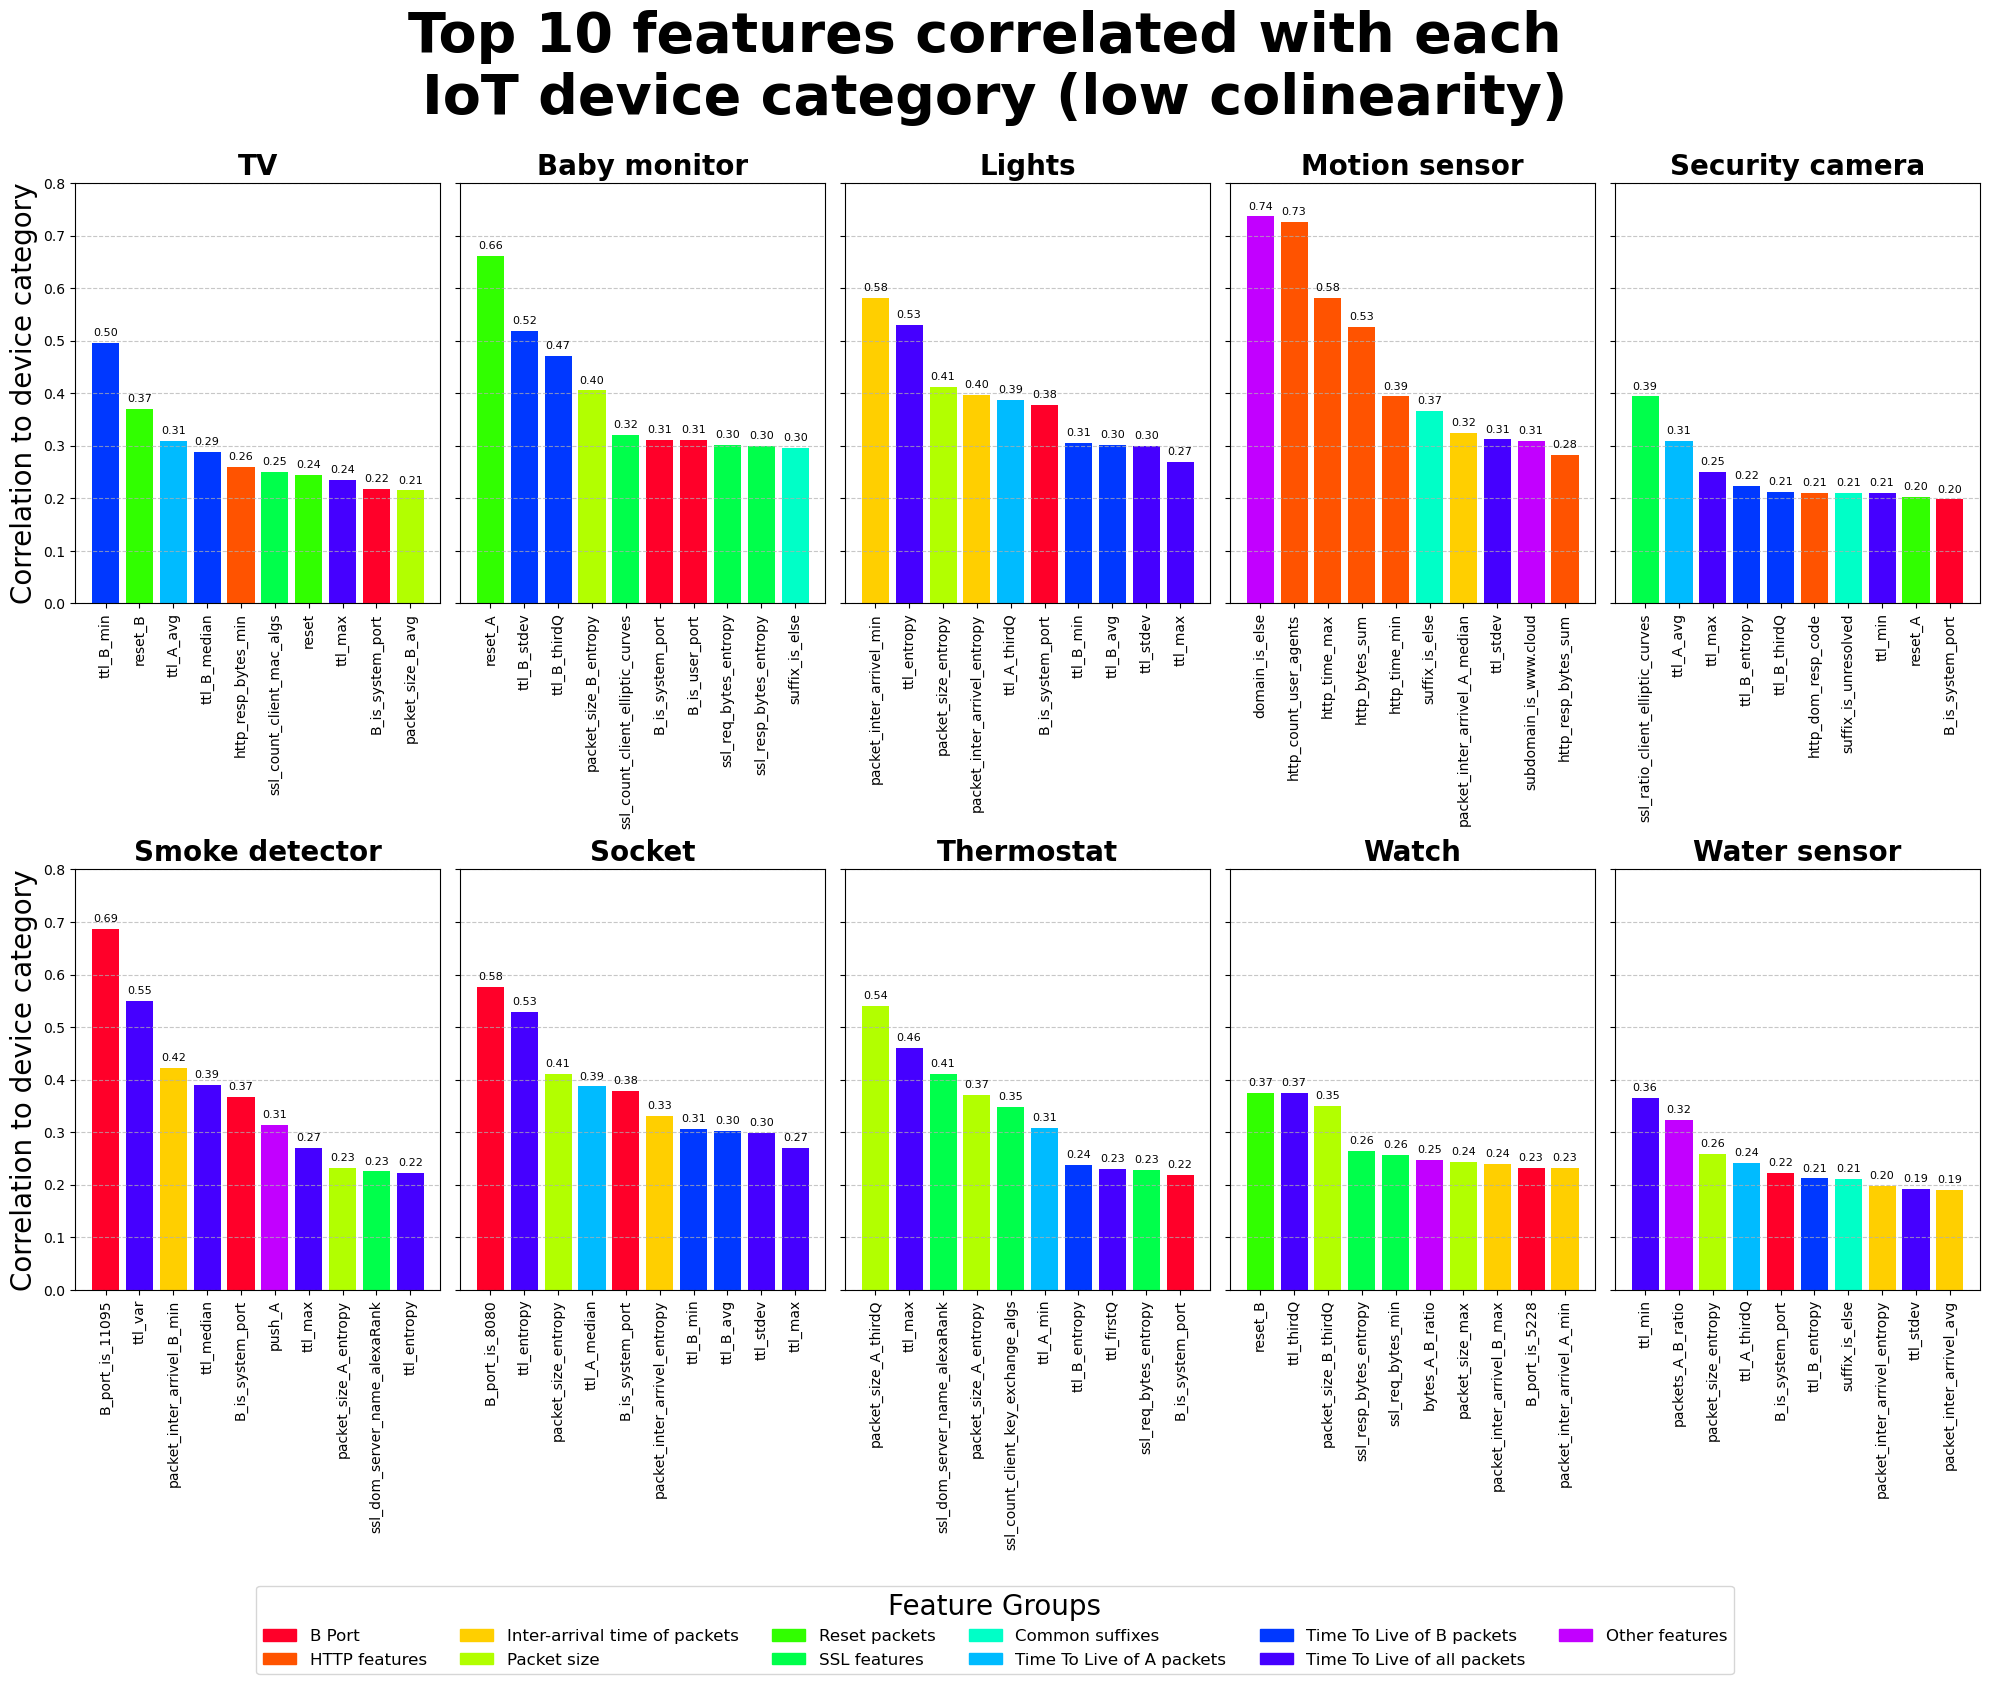

In [51]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 16), constrained_layout=False)
axes = axes.flatten()

for i, category in enumerate(device_categories):
    top_corr = corr_per_deviceCategory_top10_lowColinearity[category]
    
    ax = axes[i]
    
    colors = [cmap_features_perDeviceCategory_lowCollinearity[category][feature] for feature in top_corr]
    bars = ax.bar(range(len(top_corr)), top_corr.values(), color=colors)
    
    # value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # title of the current subplot
    ax.set_title(f'{device_category_names[category]}', fontsize=20, fontweight='bold')

    # x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr, rotation=90)
    if i % 5 == 0:  # only leftmost plots in each row get a y-label    
        ax.set_ylabel('Correlation to device category', size=20)
    else:   # plots that are not the leftmost ones in each row get no y-label or y-tick labels
        ax.set_yticklabels([])
    
    ax.set_ylim(0, 0.8)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# plot color legend
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap_feature_groups_lowCollinearity[group]) for group in features_mostCorrelated_lowColinearity_groups.keys()]
legend_labels = [feature_group_names_lowColinearity.get(group, group.replace('_', ' ').title()) 
                for group in features_mostCorrelated_lowColinearity_groups.keys()]
fig.legend(handles, legend_labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0), 
           fontsize=12, frameon=True, title='Feature Groups', title_fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=1)  # space covered by plots
plt.subplots_adjust(bottom=0.18)                # adjust the bottom margin to make room for the legend

# plot title
plt.suptitle('Top 10 features correlated with each \nIoT device category (low colinearity)', fontsize=40, fontweight='bold')
plt.show()

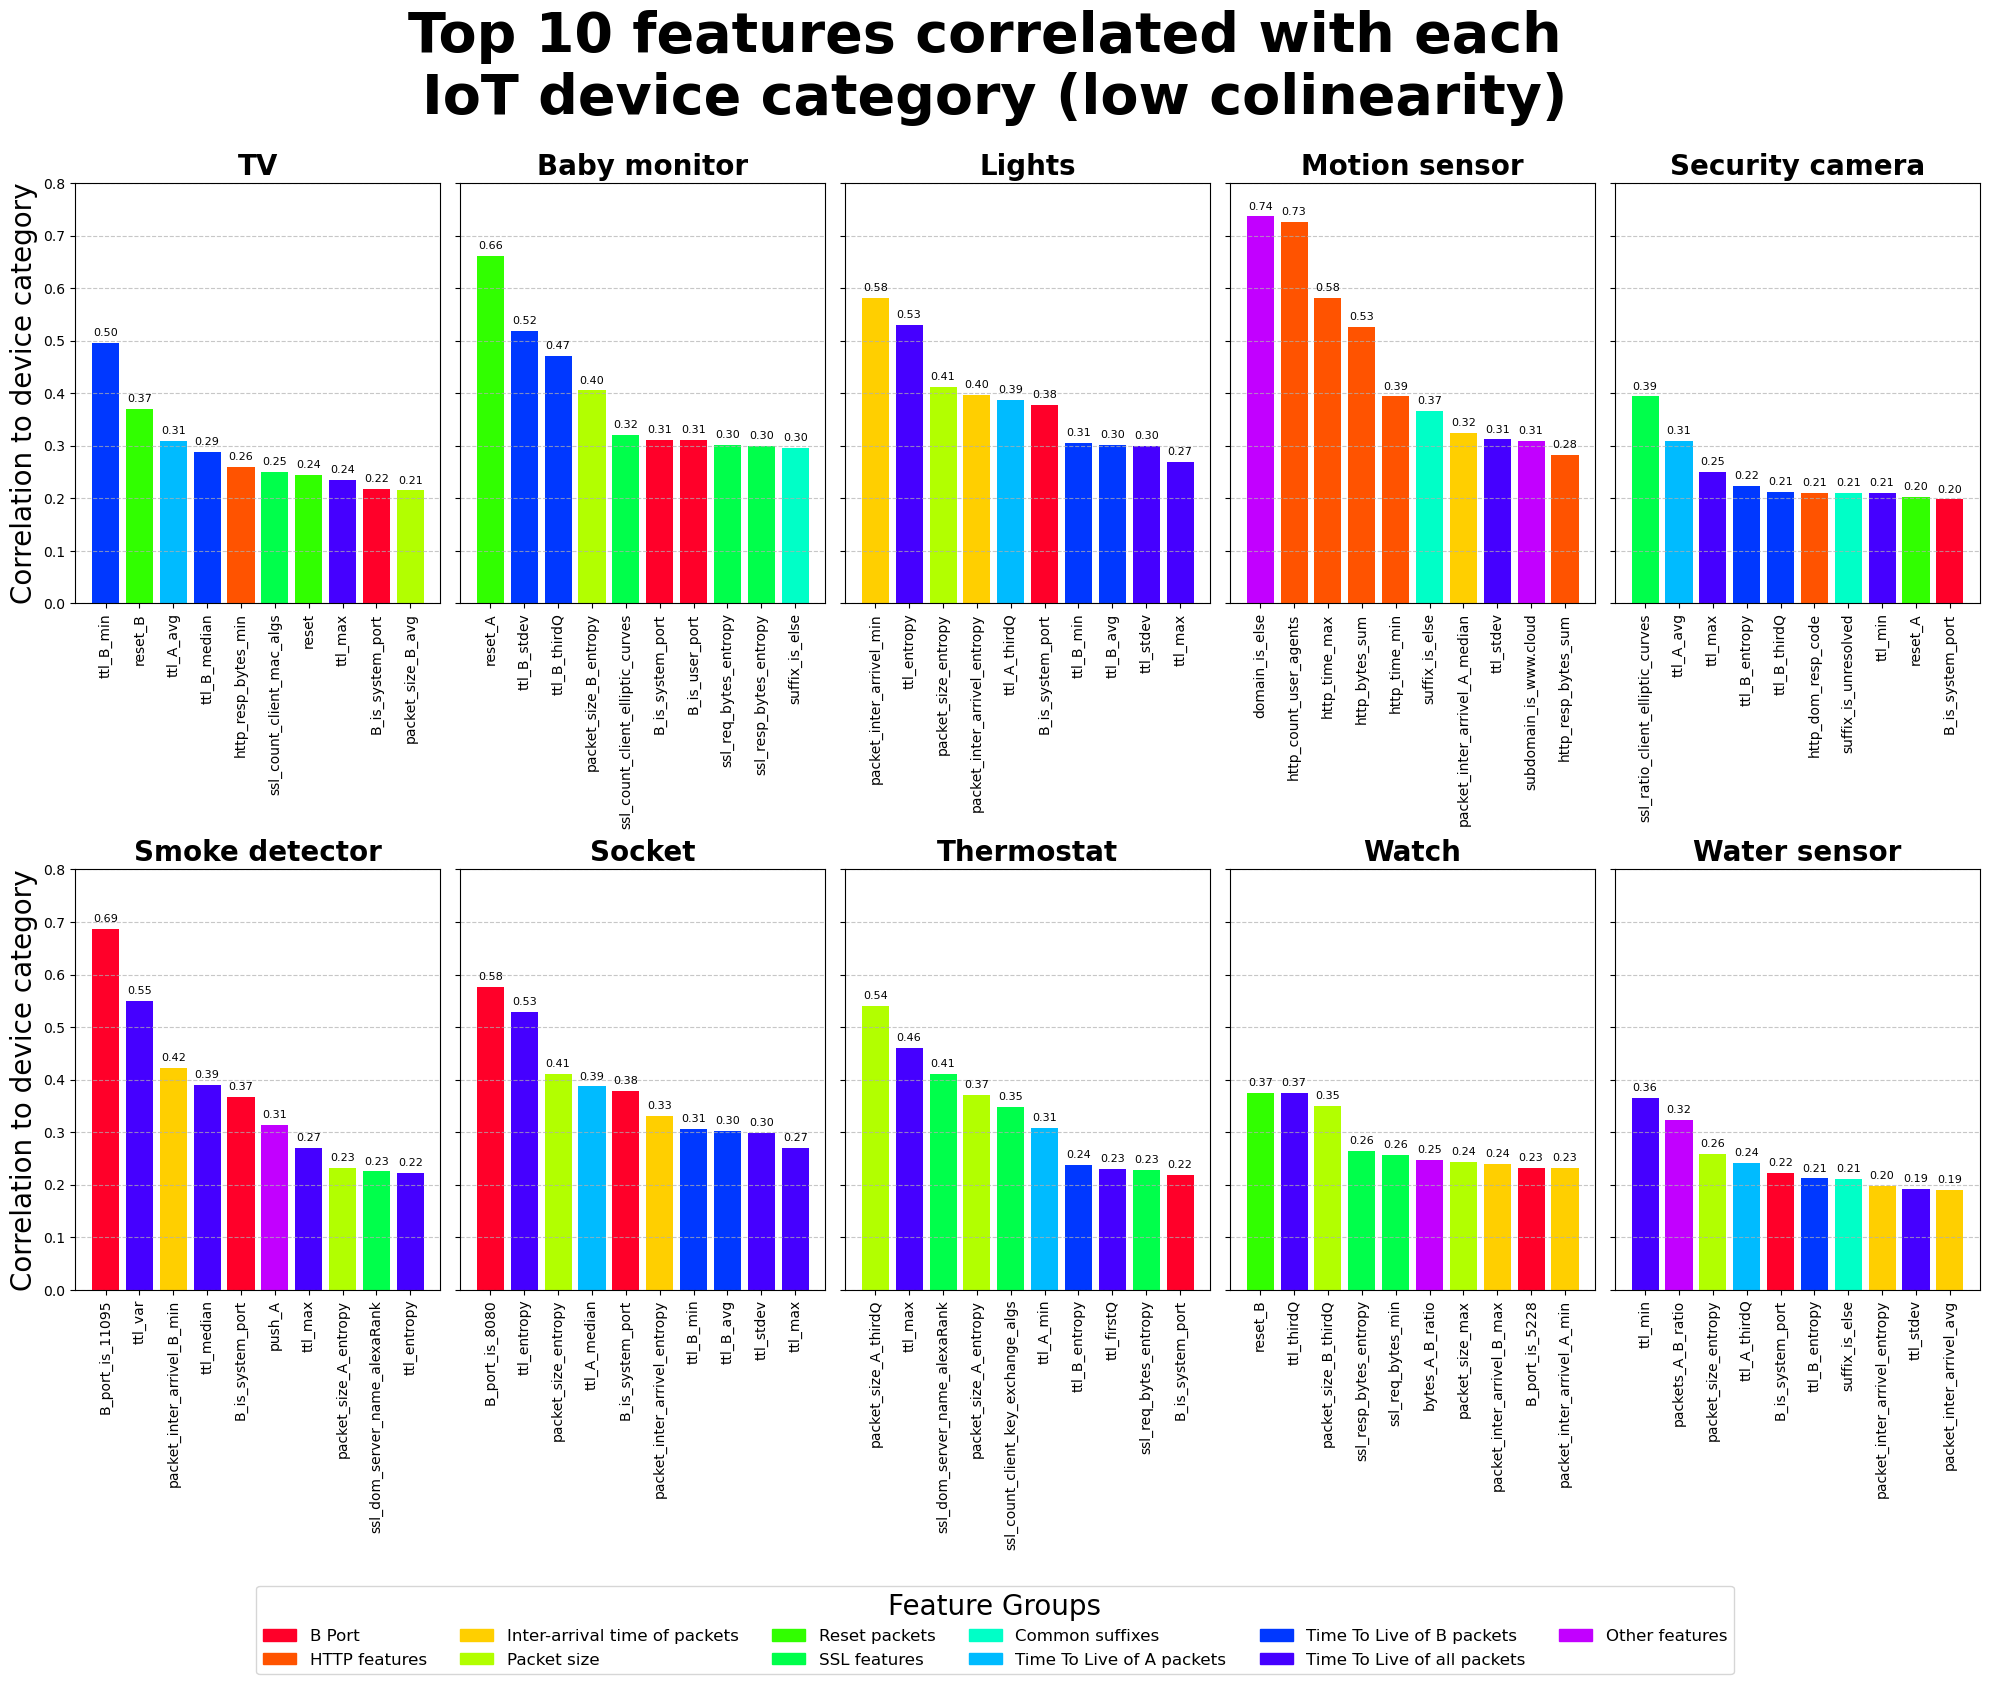

In [72]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 16), constrained_layout=False)
axes = axes.flatten()

for i, category in enumerate(device_categories):
    top_corr = corr_per_deviceCategory_top10_lowColinearity[category]
    
    ax = axes[i]
    
    colors = [cmap_features_perDeviceCategory_lowCollinearity[category][feature] for feature in top_corr]
    bars = ax.bar(range(len(top_corr)), top_corr.values(), color=colors)
    
    # value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # title of the current subplot
    ax.set_title(f'{device_category_names[category]}', fontsize=20, fontweight='bold')

    # x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr, rotation=90)
    if i % 5 == 0:  # only leftmost plots in each row get a y-label    
        ax.set_ylabel('Correlation to device category', size=20)
    else:   # plots that are not the leftmost ones in each row get no y-label or y-tick labels
        ax.set_yticklabels([])
    
    ax.set_ylim(0, 0.8)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# plot color legend
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap_feature_groups_lowCollinearity[group]) for group in features_mostCorrelated_lowColinearity_groups.keys()]
legend_labels = [feature_group_names_lowColinearity.get(group, group.replace('_', ' ').title()) 
                for group in features_mostCorrelated_lowColinearity_groups.keys()]
fig.legend(handles, legend_labels, loc='upper center', ncol=6, bbox_to_anchor=(0.5, 0), 
           fontsize=12, frameon=True, title='Feature Groups', title_fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.9], h_pad=1)  # space covered by plots
plt.subplots_adjust(bottom=0.18)                # adjust the bottom margin to make room for the legend

# plot title
plt.suptitle('Top 10 features correlated with each \nIoT device category (low colinearity)', fontsize=40, fontweight='bold')
plt.show()

In [69]:
features_mostCorrelated_lowColinearity_analysis.sort_values(by='correlation_sum', ascending=False, inplace=True)

C:\Users\randr\AppData\Local\Temp\ipykernel_25032\2877525723.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



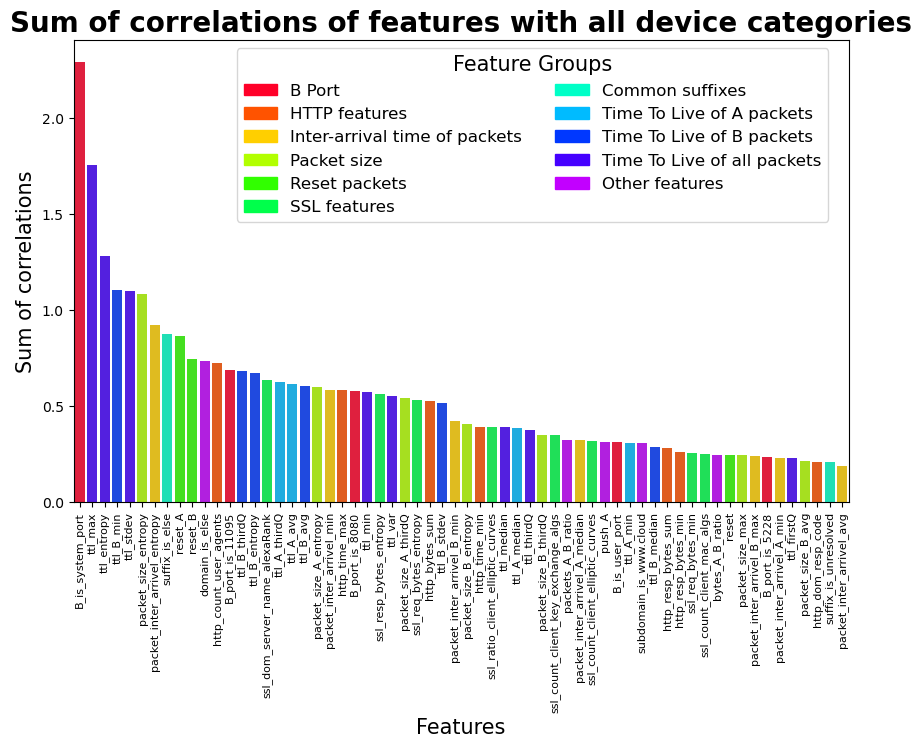

In [86]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=False)
fig = sns.barplot(
    data=features_mostCorrelated_lowColinearity_analysis, 
    y='correlation_sum',
    x=features_mostCorrelated_lowColinearity_analysis.index,
    hue='group', 
    dodge=False, 
    palette=cmap_feature_groups_lowCollinearity,
    legend=False
    )

fig.set_xticklabels(fig.get_xticklabels(), rotation=90, fontdict={'fontsize': 8})
fig.set_xlabel('Features', fontsize=15,)
fig.set_ylabel('Sum of correlations', fontsize=15)
fig.set_title('Sum of correlations of features with all device categories', fontsize=20, fontweight='bold')
handles = [plt.Rectangle((0, 0), .5, 0.5, color=cmap_feature_groups_lowCollinearity[group]) for group in features_mostCorrelated_lowColinearity_groups.keys()]
legend_labels = [feature_group_names_lowColinearity.get(group, group.replace('_', ' ').title()) 
                for group in features_mostCorrelated_lowColinearity_groups.keys()]
fig.legend(handles, legend_labels, loc='upper left', ncol=2, bbox_to_anchor=(0.2, 1), 
           fontsize=12, frameon=True, title='Feature Groups', title_fontsize=15)
plt.show()